# Lab 1: PyTorch Review

### **IMPORTANT:** There are **23** questions on this lab. Make sure you are not missing any when you submit!

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import tqdm
from sklearn.inspection import DecisionBoundaryDisplay

def plot_boundary(model, X, y, alpha=1, title=''):
    xrange = (-X[:, 0].min() + X[:, 0].max()) / 10
    yrange = (-X[:, y].min() + X[:, y].max()) / 10
    feature_1, feature_2 = np.meshgrid(
        np.linspace(X[:, 0].min() - xrange, X[:, 0].max() + xrange, 250),
        np.linspace(X[:, 1].min() - yrange, X[:, 1].max() + yrange, 250)
    )
    grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T
    y_pred = np.reshape(model.predict(torch.tensor(grid).float()).detach().numpy(), feature_1.shape)
    display = DecisionBoundaryDisplay(
        xx0=feature_1, xx1=feature_2, response=y_pred
    )
    display.plot()
    display.ax_.scatter(
        X[:, 0], X[:, 1], c=y, alpha=alpha, edgecolor="black"
    )
    plt.title(title)
    plt.show()

## Introduction to PyTorch

The most basic object in PyTorch is a `tensor`. Tensor objects behave much like the `AutogradValue` objects we are creating in the homework! We can create a `tensor` object with a given value as follows

In [2]:
x = torch.tensor(4.)
x

tensor(4.)

Performing basic operations on `tensor` objects gives tensor objects.

In [3]:
a = x ** 2 + 5
a

tensor(21.)

`tensor` objects also support reverse-mode automatic differentiation! To use this, we must specify that we will want to compute the derivative with respect to a given `tensor`. We can do this with the `requires_grad` argument.

In [4]:
x = torch.tensor(4., requires_grad=True)

Once we have a `tensor` that `requires_grad`, we can perform operations on it to compute a loss.

In [5]:
a = x ** 2 + 5
L = torch.log(a) # Functions like log must be called through torch
L

tensor(3.0445, grad_fn=<LogBackward0>)

Once we have a loss running the backward pass is done exactly as in the homework. First we call `backward()` on the loss `tensor` object, then we can access the derivative through the `grad` property of `x`.

In [6]:
L.backward()
x.grad

tensor(0.3810)

We can also create `tensor` objects that wrap arrays.

In [7]:
x = torch.tensor(np.array([3, 4, 5]))
x

tensor([3, 4, 5])

We can also just directly create tensors as we would numpy arrays

In [8]:
x = torch.tensor([3, 4, 5])
x

tensor([3, 4, 5])

Including convienience constructors.

In [9]:
print(torch.ones((5,)))
print(torch.zeros((2, 3)))

tensor([1., 1., 1., 1., 1.])
tensor([[0., 0., 0.],
        [0., 0., 0.]])


Automatic differentiation still works for arrays. In this case it gives use the gradient of the loss (hence the `grad` property).

In [10]:
x = torch.tensor([3., 4., 5.], requires_grad=True)
L = torch.sum(x ** 2)
L

tensor(50., grad_fn=<SumBackward0>)

In [11]:
L.grad

/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_19670/323164392.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:497.)
  L.grad


In [12]:
L.backward()
x.grad

tensor([ 6.,  8., 10.])

We can convert `tensor` objects back to numpy by calling `x.detach().numpy()`. (`detach` removes the variable from any automatic differentiation computations)

In [13]:
x.detach().numpy()

array([3., 4., 5.], dtype=float32)

At this point it's probably worth remarking on where the name `tensor` comes from. 

So far we've discussed 3 kinds of array objects
- **Scalars:** which are just single values (0-dimensional)
- **Vectors:** 1-dimensional arrays of numbers
- **Matrices:** 2-dimensional arrays of numbers

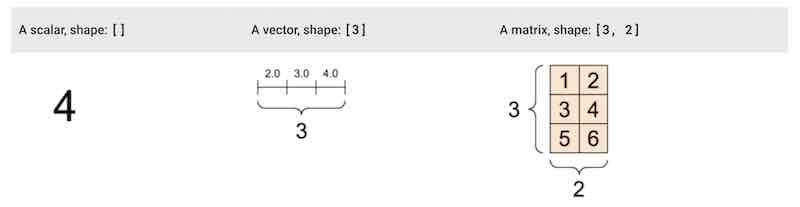

A **tensor** is the generalization of a vector or matrix to *any* number of dimensions. For example, a 3-dimensional tensor can be seen in multiple ways.

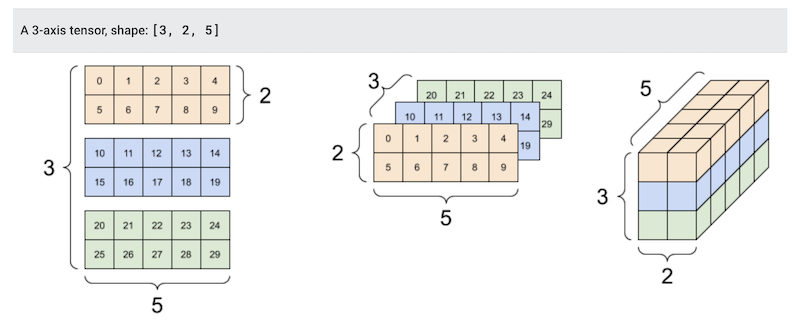

A `tensor` object can be created with any number of dimensions. For example, we could create a 2x2x2 tensor as:

In [14]:
t = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
t

tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])

Or we could create the tensor in the image using `arange` and `reshape`.

In [15]:
t = torch.arange(30).reshape((3, 2, 5))
t

tensor([[[ 0,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9]],

        [[10, 11, 12, 13, 14],
         [15, 16, 17, 18, 19]],

        [[20, 21, 22, 23, 24],
         [25, 26, 27, 28, 29]]])

4-dimensional tensors can also be visualized

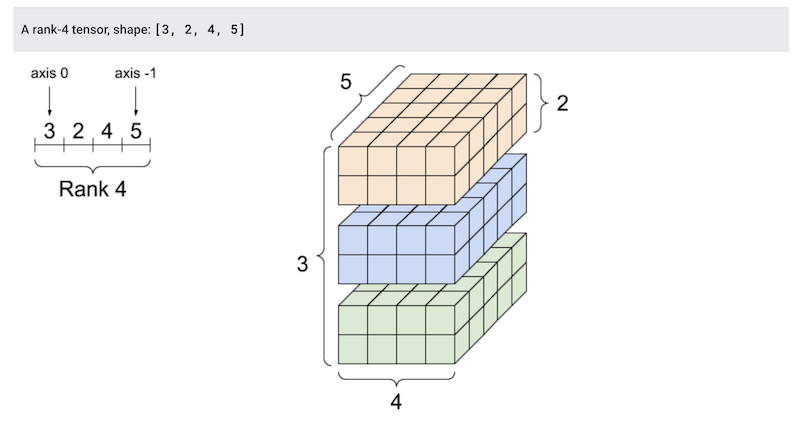

In [16]:
t = torch.ones((3, 2, 4, 5))
t.shape

torch.Size([3, 2, 4, 5])

There are some notable differences between torch and numpy when it comes to operations. The important one to watch out for at this point is matrix multiplation. In numpy we accomplished with with `np.dot`:

In [17]:
x = np.ones((4, 5))
w = np.ones((5, 2))
np.dot(x, w)

array([[5., 5.],
       [5., 5.],
       [5., 5.],
       [5., 5.]])

In PyTorch `torch.dot` only does vector dot products and thus only applies to 1-dimensional `tensor` objects:

In [18]:
x = torch.ones((4, 5))
w = torch.ones((5, 2))
# torch.dot(x, w)

Instead we use the `torch.matmul` function for this purpose

In [19]:
torch.matmul(x, w)

tensor([[5., 5.],
        [5., 5.],
        [5., 5.],
        [5., 5.]])

Recall that a square matrix $A$ defines a linear mapping: $\mathbb{R}^n\rightarrow \mathbb{R}^n$. Given a vector $\textbf{x}$, we can find the corresponding output of this mapping $\textbf{b}$ using matrix-vector multiplication: $\textbf{b}=A \textbf{x}$. We can write an example matrix-multiplication using matrix notation as:

$$\begin{bmatrix}
4 & -3 & 2 \\
6 & 5  & 1 \\
-4 & -1 & 2
\end{bmatrix} \cdot \begin{bmatrix}
1 \\
-2 \\
1
\end{bmatrix}
= \begin{bmatrix}
? \\
? \\
?
\end{bmatrix}
$$

#### **Q1** (5 points)
Perform this matrix-vector multiplication by hand and write the answer in the cell below.

$$\begin{bmatrix}
4+6+2 \\
6-10+1 \\
-4+2+2
\end{bmatrix}
= \begin{bmatrix}
12 \\
-3 \\
0 \\
\end{bmatrix}$$

<div style="page-break-after: always; visibility: hidden"> 
\pagebreak 
</div>

#### **Q2** (5 points)
In the code cell below, create the matrix $A$ and the vector $\textbf{x}$ shown above, using PyTorch. Then use the `torch.matmul` function to find the output of the mapping $\textbf{b} = A\textbf{x}$. Verify that the answer matches what you derived above.

In [20]:
# Fill answers here
A = torch.tensor([[4., -3., 2.], [6., 5., 1.], [-4., -1., 2.]])
A
x = torch.tensor([1., -2., 1.])
b =  torch.matmul(A, x)

print(b)

tensor([12., -3.,  0.])


Often we will have access to the transformed vector $\textbf{b}$ and need to find the orginal vector $\textbf{x}$. To do this we need to *solve* the system of linear equations $A\textbf{x}=\textbf{b}$ for $\textbf{x}$.
$$\begin{bmatrix}
4 & -3 & 2 \\
6 & 5  & 1 \\
-4 & -1 & 2
\end{bmatrix} \cdot \begin{bmatrix}
? \\
? \\
?
\end{bmatrix} = \begin{bmatrix}
2 \\
-1 \\
3
\end{bmatrix}
$$

#### **Q3** (5 points)
Find the missing $\textbf{x}$ in the equation above using the `torch.linalg.solve` function and verify that $A\textbf{x}=\textbf{b}$.

In [21]:
# Fill answer here (A is the same matrix from above)
b = torch.tensor([2., -1., 3.])
x = torch.linalg.solve(A, b)

print(x)

torch.matmul(A, x)

tensor([-0.1750, -0.2000,  1.0500])


tensor([ 2.0000, -1.0000,  3.0000])

In linear algebra you may have learned how to solve a system of linear equations using Gaussian elimination. Here we will implement an alternative approach known as *Richardson iteration*. In this method we start with an inital guess for the solution: $\textbf{x}^{(0)}$, then we will iteratively update this guess until the solution is reached. Given a matrix $A$, a target $\textbf{b}$ and a current guess $\textbf{x}^{(k)}$, we can compute the Richardson update as:

$$\textbf{x}^{(k+1)} \leftarrow \textbf{x}^{(k)} + \omega \left(\textbf{b} - A\textbf{x}^{(k)}\right)$$

Here $\omega$ is a constant that we can choose to adjust the algorithm. We will set $\omega = 0.1$.

#### **Q4** (5 points)
Fill in the Richardson iteration function below and apply it to the system of linear equations from above using 100 updates. Verify that if gives a similar answer to `torch.linalg.solve`.

In [22]:
# Fill in function below
def richardson_iter(x_guess, A, b, omega=0.1):
    new_x_guess = x_guess + omega*(b-torch.matmul(A, x_guess))
    return new_x_guess

x_guess = torch.zeros(3)
for i in range(100):
    x_guess = richardson_iter(x_guess, A, b)

print(x_guess, x)

tensor([-0.1750, -0.2000,  1.0500]) tensor([-0.1750, -0.2000,  1.0500])


Recall that the length of a vector is given by it's *two-norm*, which is defined as:
$$\|\mathbf{x}\|_2 = \sqrt{\sum_{i=1}^n x_i^2}.$$


Correspondingly, the (Euclidian) distance between two points $\mathbf{a}, \mathbf{b} \in \mathbb{R}^n$ can be written as $\|\mathbf{a} - \mathbf{b}\|_2$. As a convenient measure of error for our Richardson iteration algorithm, we will use the *squared Euclidean distance*. For a guess $\mathbf{x}^{(k)}$ we will compute the error $e^{(k)}$ as:
$$e^{(k)} = \|A\mathbf{x}^{(k)} - \mathbf{b}\|_2^2$$

In expanded form, this would be written as:
$$e^{(k)} = \sum_{i=1}^n \left(\sum_{j=1}^n A_{ij}x^{(k)}_j - b_i\right)^2$$

#### **Q5** (10 points)
Write a function to compute the error of a given guess. Then run Richardson iteration again for 100 steps, computing the error at each step. Finally create a plot of the error for each step (error vs. step). [Plot reference](https://cs152.github.io/lecture1-background/notes.html#scatterplots-and-line-plots)

*Hint: recall that basic operations in numpy (addition, subtraction, powers) are performed element-wise.*

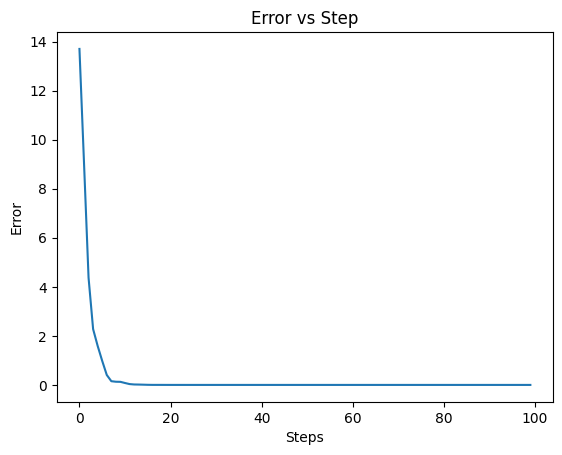

In [23]:
# Fill in function below
def error(x_guess, A, b):
    err = torch.matmul(torch.matmul(A, x_guess) - b, torch.matmul(A, x_guess) - b)
    return err

# Add code to plot the error over time
e = []
x_guess = torch.zeros(3)
for step in range(100):
    x_guess = richardson_iter(x_guess, A, b)
    e.append(error(x_guess, A, b))
plt.plot([i for i in range(100)], e)
plt.xlabel('Steps')
plt.ylabel('Error')
plt.title('Error vs Step')
plt.show()

#### **Q6** (10 points)
Derive the partial derivative of the error with respect to a single entry of $\mathbf{x}^{(k)}$ (without loss of generality, we will say $x^{(k)}_1$). Work in the *expanded form* as in the equation above, writing your answer in the markdown cell below.

*Hint: You may find it helpful to refer to the latex equation cheatsheet on the course website. You may show intermediate steps here or as handwritten work as a separate file in the repository. The final answer should be filled in here.*

**EDIT THIS CELL WITH YOUR ANSWER**

$$\frac{\partial e^{(k)}}{\partial x^{(k)}_1}= 2\sum_{i=1}^{n}A_{i1}\left(\sum_{j=1}^{n}A_{ij}x_{j}^{(k)}-b_i\right)$$

In practice, we will likely want to compute the derivative with respect to *all* entries of $\mathbf{x}$:
$$\frac{\partial e^{(k)}}{\partial \mathbf{x}^{(k)}} = \begin{bmatrix}
\frac{\partial e^{(k)}}{\partial x^{(k)}_1} \\
 \vdots \\
\frac{\partial e^{(k)}}{\partial x^{(k)}_n}
\end{bmatrix}$$

We could just compute each entry separately using the formula you just derived, but ideally we'd like to be able to write it in the more compact matrix-vector notation that we've seen.

Recall that we can write the error formulation as:
$$e^{(k)} = \|A\mathbf{x}^{(k)} - \mathbf{b}\|_2^2 = (A\mathbf{x}^{(k)} - \mathbf{b})^T(A\mathbf{x}^{(k)} - \mathbf{b})$$

#### **Q7** (10 points)

In the equation above, imagine the case where the variables are all scalars, so $A \rightarrow a$, $\mathbf{b} \rightarrow b$ and $\mathbf{x} \rightarrow x$. In this case we can write the error as:
$$e^{(k)} = (ax^{(k)} - b)(ax^{(k)} - b) = (ax^{(k)} - b)^2$$

Take the derivate of the above expression with respect to $x^{(k)}$, then substitute back in the matrix-vector notation: $a \rightarrow A$, $b \rightarrow \mathbf{b}$ and $x \rightarrow \mathbf{x}$. 

*Note that while scalar multiplication is communative ($ax = xa$), matrix-vector multiplication is **not** ($A\mathbf{x} \neq \mathbf{x}^T A$). If you maintain the order of multiplications in your derivative, this should give you the correct answer.*

**EDIT THIS CELL WITH YOUR ANSWER**

$$\frac{d e^{(k)}}{d \mathbf{x}^{(k)}}= 2A^{T}(A\mathbf{x}^{(k)}-\mathbf{b})$$

#### **Q8** (5 points)
Expand the above expression at index 1 and show that we get the same answer as **Q6**.

\begin{align*}
    \frac{d e^{(k)}}{d \mathbf{x}^{(k)}}= 2A^{T}(A\mathbf{x}^{(k)}-\mathbf{b})\\
\end{align*}
At index 1 we have
\begin{align*}
    \frac{d e^{(k)}}{dx_1^{(k)}}= [2A^{T}(A\mathbf{x}^{(k)}-\mathbf{b})]_1\\
\end{align*}
Let
\begin{align*}
    \mathbf{z} = A\mathbf{x}^{(k)}-\mathbf{b}\\
    (A^T\mathbf{z})_1 = \sum_{i=1}^nA_{i1}r_i
\end{align*}
Now,
\begin{align*}
    \frac{d e^{(k)}}{dx_1^{(k)}} &= 2\sum_{i=1}^nA_{i1}r_i\\
    &= 2\sum_{i=1}^nA_{i1}\left(\sum_{j=1}^nA_{ij}x_j^{(k)}-b_i\right)
\end{align*}

##  Working with batches of vectors

Recall that a vector can also be seen as either an $n \times 1$ matrix (column vector) or a $1 \times n$ matrix (row vector).

$$\text{Column vector: } \mathbf{x} = \begin{bmatrix}
x_1 \\
x_2 \\
x_3
\end{bmatrix}, \quad \text{Row vector: } \mathbf{x}^T = \begin{bmatrix}
x_1 & x_2 & x_3
\end{bmatrix}$$

Note that we use the same notation for both as they refer to the same concept (a vector). The difference becomes relevant when we consider matrix-vector multiplication. We can write matrix-vector multiplication in two ways: $$\text{Matrix-vector: }A\mathbf{x} = \mathbf{b}, \quad \text{Vector-matrix: }\mathbf{x}^TA^T= \mathbf{b}^T$$
In *matrix-vector multiplication* we treat $\textbf{x}$ as a column vector ($n \times 1$ matrix), while in *vector-matrix multiplication* we treat it as a row vector ($n \times 1$ matrix). Transposing $A$ for left multiplication ensures that the two forms give the same answer.

#### **Q9** (5 points)
Using the previously defined $\mathbf{x}$, create an explicit column vector and row vector. Then using the previously defined $A$, verify that the matrix-vector and vector-matrix multiplications shown above do produce the same resultant vector $\mathbf{b}$.

*Hint: Recall that* `torch.matmul` *is also used for matrix-matrix multiplication. The values of $\mathbf{x}$ and $A$ are:*
$$\mathbf{x} = \begin{bmatrix}
1 \\
-2 \\
1
\end{bmatrix}, \quad A = \begin{bmatrix}
4 & -3 & 2 \\
6 & 5  & 1 \\
-4 & -1 & 2
\end{bmatrix}$$

In [24]:
# Fill in code here
x_col = torch.tensor([1., -2., 1.])
x_row = x_col.reshape((1, 3)).float()

print(torch.matmul(A, x_col))
print(torch.matmul(x_row, A.t()))

tensor([12., -3.,  0.])
tensor([[12., -3.,  0.]])


The distinction between row and column vectors also affects the behaivior of other operations on `np.array` objects, particularly through the concept of [*broadcasting*](https://cs152.github.io/lecture1-background/notes.html#element-wise-matrix-operations).

#### **Q10** (5 points)
Consider a $3 \times 3$ matrix of all ones as defined in code below, along with the 1-d vector $\mathbf{x}$.

In [25]:
ones = torch.ones((3, 3))
x = torch.tensor([1, -2, 1])
ones

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])

Complete the line of code below such that the result of the operation is:

$$\begin{bmatrix}
1 & -2 & 1 \\
1 & -2  & 1 \\
1 & -2 & 1
\end{bmatrix}$$

*Hint: You should replace `SHAPE` with an appropriate shape for broadcasting and `OPERATION` with an appropriate operation (e.g. `+, -, *, /`)*

In [26]:
ones * x.reshape(1, 3)

tensor([[ 1., -2.,  1.],
        [ 1., -2.,  1.],
        [ 1., -2.,  1.]])

Throughout this course we will typically use row vectors and vector-matrix multiplication, as this is more conventional in neural-network literature. The concept of row and column vectors becomes handy when transforming *collections* of vectors.

Recall that a matrix can be seen as a collection of vectors. In numpy we can create a matrix from a list of (1- dimensional) vectors using the `np.stack` function. This function assumes that the vectors are row vectors creating the matrix as follows:
$$\begin{bmatrix}
3 & 1 & -2
\end{bmatrix},\ \begin{bmatrix}
4 & 5 & 3
\end{bmatrix},\ \begin{bmatrix}
-2 & -1 & 5
\end{bmatrix}\quad \overset{\text{np.stack}}{\longrightarrow} \begin{bmatrix}
3 & 1 & -2 \\
4 & 5 & 3 \\
-2 & -1 & 5
\end{bmatrix} $$

We will call this matrix $X$ to denote that it is a collection of vectors, rather than a single vector ($\mathbf{x}$).

#### **Q11** (5 points)
Create this matrix in numpy using th `np.stack` function.

In [27]:
# Fill code here

X = np.stack([[3,1,-2], [4,5,3], [-2,-1,5]])
print(X)

[[ 3  1 -2]
 [ 4  5  3]
 [-2 -1  5]]


When taken together as a matrix in this way, we can apply the linear mapping $A$ to all vectors using matrix-matrix multiplication:
$$B=XA^T$$

Let's put this into practice with a visual example.

#### **Q12** (5 points)
Create a $20 \times 3$ matrix, `circle`, in numpy of the following form

$$ \begin{bmatrix} \sin(\theta_1) & \cos(\theta_1)  & 1 \\
\sin(\theta_2) & \cos(\theta_2)  & 1 \\
\vdots & \vdots & \vdots \\
\sin(\theta_{20}) & \cos(\theta_{20})  & 1 \\
 \end{bmatrix}$$
 Where $\theta_1...\theta_{20}$ are evenly spaced between $0$ and $2\pi$.

In [28]:
import math
theta = torch.linspace(0, 2 * torch.pi, 20) # Generates 20 evenly-spaced numbers between 0 and 2π
print(theta)
# Fill in your code here

circle = np.stack([[math.sin(i), math.cos(i), 1] for i in theta])
print(circle)

tensor([0.0000, 0.3307, 0.6614, 0.9921, 1.3228, 1.6535, 1.9842, 2.3149, 2.6456,
        2.9762, 3.3069, 3.6376, 3.9683, 4.2990, 4.6297, 4.9604, 5.2911, 5.6218,
        5.9525, 6.2832])
[[ 0.00000000e+00  1.00000000e+00  1.00000000e+00]
 [ 3.24699466e-01  9.45817243e-01  1.00000000e+00]
 [ 6.14212707e-01  7.89140514e-01  1.00000000e+00]
 [ 8.37166473e-01  5.46948167e-01  1.00000000e+00]
 [ 9.69400263e-01  2.45485500e-01  1.00000000e+00]
 [ 9.96584494e-01 -8.25793288e-02  1.00000000e+00]
 [ 9.15773335e-01 -4.01695406e-01  1.00000000e+00]
 [ 7.35723927e-01 -6.77281554e-01  1.00000000e+00]
 [ 4.75947417e-01 -8.79473738e-01  1.00000000e+00]
 [ 1.64594620e-01 -9.86361298e-01  1.00000000e+00]
 [-1.64594792e-01 -9.86361270e-01  1.00000000e+00]
 [-4.75947570e-01 -8.79473655e-01  1.00000000e+00]
 [-7.35724045e-01 -6.77281426e-01  1.00000000e+00]
 [-9.15773405e-01 -4.01695246e-01  1.00000000e+00]
 [-9.96584529e-01 -8.25789169e-02  1.00000000e+00]
 [-9.69400220e-01  2.45485670e-01  1.00000000e+00]

The code we just wrote creates a matrix corresponding to a collection of $20$ row vectors of length 3. Each vector represents a point on the unit circle where the first entry is the x-coordinate, the second entry is the y-coordinate and the third entry is always $1$:
$$ \begin{bmatrix} x & y & 1 \end{bmatrix}$$

#### **Q13** (5 points)
Plot the set of 20 points in `circle` using the `plt.plot` function. *Use only the x and y coordinates, ignoring the column of 1s.*

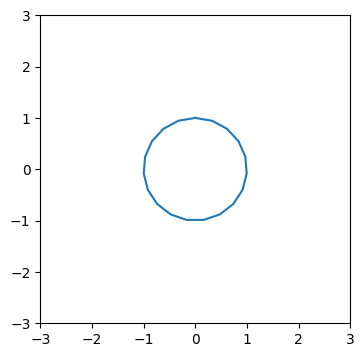

In [29]:
plt.figure(figsize=(4, 4))
plt.xlim(-3, 3)
plt.ylim(-3, 3)

# Fill your code here
plt.plot(circle[:,0], circle[:,1])

#### **Q14** (5 points)
Transform all the vectors in `circle` with the matrix $A$ using a single call to `np.dot`. Then plot the original set of points in black and the transformed points in red using the `plt.plot` function.

*You might also consider why we added the extra column of 1s! We will discuss the answer to that in class. $A$ is the same matrix from q1.*

In [30]:
# Fill your code here
transformed_circle = np.dot(circle, A.t())

/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_19670/179003177.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  transformed_circle = np.dot(circle, A.t())


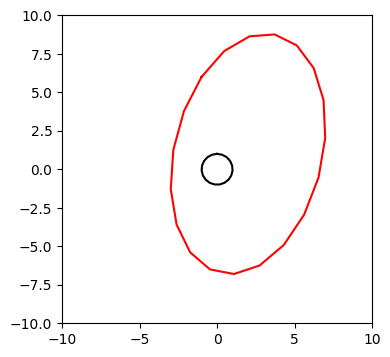

In [31]:
plt.figure(figsize=(4, 4))
plt.xlim(-10, 10)
plt.ylim(-10, 10)

# Fill your code here
plt.plot(circle[:,0], circle[:,1], color = 'black')
plt.plot(transformed_circle[:,0], transformed_circle[:,1], color = 'red')

#### **Q15** (5 points)
Finally, shift all the vectors in `transformed_circle` by the vector $\mathbf{b}$ defined below, that is, add $\mathbf{b}$ to every *row* of the output matrix. Again plot the original set of points in black and the transformed points in red using the `plt.plot` function.

*Hint: the solution to this question should **not** involve any loops, instead use broadcasting.*

In [32]:
# Fill your code here
b = torch.tensor([-0.5, 1.2, 0])
transformed_circle = torch.tensor(transformed_circle)
transformed_circle = transformed_circle + b
print(transformed_circle)

tensor([[-1.5000,  7.2000,  1.0000],
        [-0.0387,  8.8773, -0.2446],
        [ 1.5894,  9.8310, -1.2460],
        [ 3.2078,  9.9577, -1.8956],
        [ 4.6411,  9.2438, -2.1231],
        [ 5.7341,  7.7666, -1.9038],
        [ 6.3682,  5.6862, -1.2614],
        [ 6.4747,  3.2279, -0.2656],
        [ 6.0422,  0.6583,  0.9757],
        [ 5.1175, -1.7442,  2.3280],
        [ 3.8007, -3.7194,  3.6447],
        [ 2.2346, -5.0531,  4.7833],
        [ 0.5889, -5.6008,  5.6202],
        [-0.9580, -5.3031,  6.0648],
        [-2.2386, -4.1924,  6.0689],
        [-3.1141, -2.3890,  5.6321],
        [-3.4895, -0.0883,  4.8017],
        [-3.3243,  2.4604,  3.6677],
        [-2.6362,  4.9809,  2.3530],
        [-1.5000,  7.2000,  1.0000]], dtype=torch.float64)


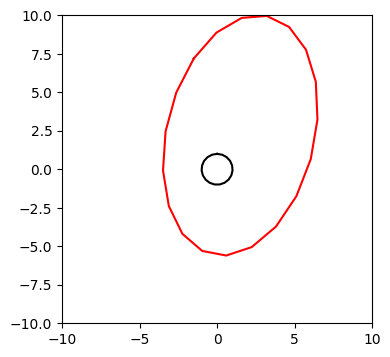

In [33]:
plt.figure(figsize=(4, 4))
plt.xlim(-10, 10)
plt.ylim(-10, 10)

# Fill your code here
plt.plot(circle[:,0], circle[:,1], color = 'black')
plt.plot(transformed_circle[:,0], transformed_circle[:,1], color = 'red')

## Logistic Regression

Let's continue to the logistic regression model for making predictions on binary data. Recall the the prediction function for logistic regression can be written as:

$$f(\mathbf{x}) = \mathbb{I}(\mathbf{x}^T\mathbf{w} \geq 0)$$

The estimated probability of $y=1$ as:
$$p(y=1\mid \mathbf{x}, \mathbf{w}) = \sigma(\mathbf{x}^T\mathbf{w})$$

Also recall that the negative log-likelihood loss for logistic regression can be written as:

$$\mathbf{NLL}(\mathbf{w}, \mathbf{X}, \mathbf{y})=-\sum_{i=1}^N \log \sigma\big((2 y_i - 1)\mathbf{x}_i^T\mathbf{w}\big)$$

and it's gradient with respect to $\mathbf{w}$ is (*remember we can use PyTorch to "derive" this for us!*):
$$\nabla_{\mathbf{w}}\mathbf{NLL}(\mathbf{w}, \mathbf{X}, \mathbf{y})=-\sum_{i=1}^N \big(1 - \sigma((2 y_i - 1)\mathbf{x}_i^T\mathbf{w})\big) \big(2 y_i - 1\big)\mathbf{x}_i$$


PyTorch has many handy built-in functions for machine learning that numpy doesn't have, such as `sigmoid`.

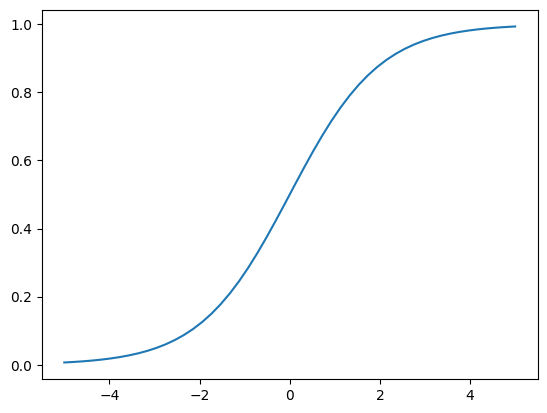

In [34]:
x = torch.linspace(-5, 5, 50)
s = torch.sigmoid(x)
plt.plot(x, s)

This makes it very easy to implement logistic regression. 

In [35]:
class LogisticRegression:
    def __init__(self, dims):
        self.weights = torch.ones((dims,), requires_grad=True)
        self.bias = torch.zeros((), requires_grad=True)

    def predict_probability(self, X):
        f_X = torch.matmul(X, self.weights) + self.bias
        return torch.sigmoid(f_X)

    def predict(self, X):
        return self.predict_probability(X) > 0.5


Let's try loading a dataset, converting it to `tensor` and making predictions

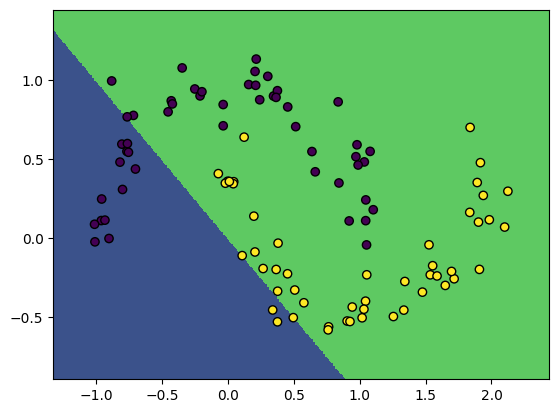

In [36]:
X, y = make_moons(noise=0.1)
X, y = torch.tensor(X).float(), torch.tensor(y)

model = LogisticRegression(2)
plot_boundary(model, X, y)

When working with PyTorch, it is convention to separate the loss function from the model, where the loss function will just take predictions and labels.

In [37]:
def NLL(pred, y):
    LL = y * torch.log(pred) + (1. - y) * torch.log(1. - pred)
    return -LL.sum()

## Gradient descent

Gradient descent is also implemented in PyTorch in the `optim` module.

In [38]:
from torch import optim

Gradient descent works a bit differently in PyTorch than what we've seen. We first need to construct a gradient descent *object* which specifies which values we're optimizing and what the learning rate will be. We specify the values to optimize by simply passing a list of weights/parameters to the constructor.

In PyTorch, basic gradient descent is encapsulated in the `optim.SGD` class (`SGD` stands for *stochastic gradient descent*, we'll talk about what *stochastic* means in this context next week.)

In [39]:
optimizer = optim.SGD([model.weights, model.bias], lr=0.1)

Notice that this object doesn't even take in the function we're trying to optimize, only the inputs. We need to call the function ourselves *and* run `backward()` to compute the gradients. 

In [40]:
predictions = model.predict_probability(X)
loss = NLL(predictions, y)
loss.backward()


Let's look at our model `weights`

In [41]:
model.weights
model.weights.grad

tensor([-4.8819, 23.2671])

We can take a single step of gradient descent using the `step` method of the optimizer.

In [42]:
optimizer.step()
model.weights

tensor([ 1.4882, -1.3267], requires_grad=True)

We see that this actually updates the weights themselves!

It's important to note that in PyTorch, calling `backward` does **not** clear the value stored in grad. So computing the gradient multiple times will result in updates to the gradient.

In [43]:
print(model.weights.grad)
NLL(model.predict_probability(X), y).backward()
print(model.weights.grad)
NLL(model.predict_probability(X), y).backward()
print(model.weights.grad)

tensor([-4.8819, 23.2671])
tensor([-16.5135,  27.3342])
tensor([-28.1450,  31.4012])


We can clear the stored gradients using the optimizer.

In [44]:
optimizer.zero_grad()
print(model.weights.grad)

None


So far we've only taking a single step of gradient descent. In order to run many steps, we need to write a loop to do everything we just saw.

In [45]:
for i in range(10):
    predictions = model.predict_probability(X)
    loss = NLL(predictions, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(loss.item())

49.23303985595703
47.19414520263672
36.620628356933594
34.37439727783203
32.638671875
31.851316452026367
31.326274871826172
31.00820541381836
30.786470413208008
30.632183074951172


We should now see that our model has been optimized!

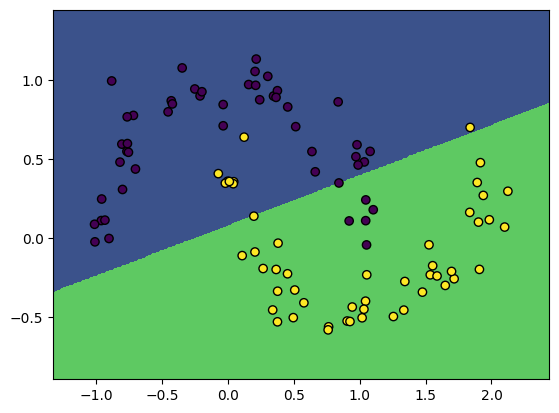

In [46]:
plot_boundary(model, X, y)

## Alternative losses

Our original goal for classification was simply to maximize the number of correct classifications we'd make. Using accuracy as a loss function looked something like this:

$$\mathbf{Acc.}(\mathbf{w}, \mathbf{X}, \mathbf{y})=-\sum_{i=1}^N \mathbb{I}\big((2 y_i - 1)\mathbf{x}_i^T\mathbf{w} \geq 0 \big)$$

Which unfortunately wasn't differentiable and therefore we couldn't optimize it with gradient descent.

The maximum likelihood principal helped us derive a useful loss function for classification:

$$\mathbf{NLL}(\mathbf{w}, \mathbf{X}, \mathbf{y})=-\sum_{i=1}^N \log \sigma\big((2 y_i - 1)\mathbf{x}_i^T\mathbf{w}\big)$$


(and had the additional benefit of letting us estimate *probabilities*). But as we saw with linear regression that we're not limited to thinking about things from the probabilistic perspective. Now that we've seen what a reasonable loss function for classification looks like, we could try some variations with similar properties.


Let's consider the **exponential loss**:

$$\mathbf{ExpLoss}(\mathbf{w}, \mathbf{X}, \mathbf{y})=\sum_{i=1}^N \exp\big(-(2 y_i - 1)\mathbf{x}_i^T\mathbf{w}\big)$$

*Note that $\exp(x) = e^x$*

Plotting this we see that just like negative log-likelihood, the loss monotonically increases as we get further from a correct prediction, which is what we'd like!

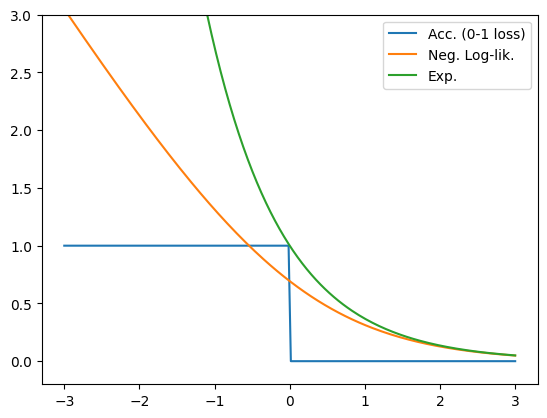

In [47]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
yxw = np.linspace(-3, 3, 200)
acc = np.where(yxw > 0, 0., 1.)
nll = -np.log(sigmoid(yxw))
exp = np.exp(-yxw)

plt.plot(yxw, acc, label='Acc. (0-1 loss)')
plt.plot(yxw, nll, label='Neg. Log-lik.')
plt.plot(yxw, exp, label='Exp.')
plt.ylim((-0.2, 3))
plt.legend();

#### **Q16:** Exponential loss gradient (10 points)
Derive the gradient of the exponential loss with respect to $\mathbf{w}$, the weight vector for the linear model.


\begin{align*}
\nabla_{\mathbf{w}} \textbf{ExpLoss}(\mathbf{W}, \mathbf{X}, \mathbf{y}) &= \frac{\delta}{\delta \mathbf{w}}\sum_{i=1}^N \exp\big(-(2 y_i - 1)\mathbf{x}_i^T\mathbf{w}\big) \\
& = \sum_{i=1}^N \frac{\delta}{\delta \mathbf{w}} \exp\big(-(2 y_i - 1)\mathbf{x}_i^T\mathbf{w}\big) \\
& = \sum_{i=1}^N \exp\big(-(2 y_i - 1)\mathbf{x}_i^T\mathbf{w}\big)\big(-(2 y_i - 1)\mathbf{x}_i\big)
\end{align*}

#### **Q17:** Exponential loss comparison (5 points)

Copy and modify the code above to train a new **exponential-loss** regression model and plot the decision boundary.

121.40040588378906
94.38320922851562
89.99118041992188
88.10399627685547
86.87934875488281
85.98931121826172
85.30358123779297
84.75482940673828
84.30378723144531
83.92562866210938
83.60356140136719
83.32579040527344
83.08367156982422
82.87071990966797
82.68193054199219
82.51339721679688
82.3620376586914
82.22532653808594
82.10123443603516
81.98806762695312


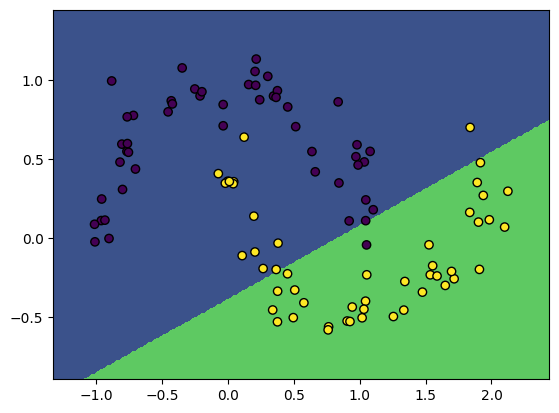

In [48]:
def EXPLoss(pred, y):
    EL = torch.exp(-(2*y-1)*pred)
    return EL.sum()

model = LogisticRegression(2)
optimizer = optim.SGD([model.weights, model.bias], lr=0.1)
for i in range(20):
    predictions = model.predict_probability(X)
    loss = EXPLoss(predictions, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(loss.item())
    

plot_boundary(model, X, y)

What differences (if any) do you notice between this and the log-likelihood loss?

There is greater loss from EXP loss compared with log-likelihood loss

#### **Q18:** Linear losses (5 points)

Note that both the negative log-likelihood and exponential losses are strictly positive, and threrefore bounded below by 0. **Why is having a lower bound a desirable property for a classification loss?**

For instance, why not simply use a linear loss?

$$\mathbf{Loss}(\mathbf{w}, \mathbf{X}, \mathbf{y})=-\sum_{i=1}^N (2 y_i - 1)\mathbf{x}_i^T\mathbf{w}$$

*Hint: If you're unsure, you could try modifying the code above to use a linear loss and see what happens!*

2.2917287349700928
-12.203180313110352
-24.95108413696289
-27.758914947509766
-28.996625900268555
-29.75490951538086
-30.291521072387695
-30.70343589782715
-31.0360050201416
-31.313695907592773
-31.55112075805664
-31.75770378112793
-31.93990135192871
-32.102325439453125
-32.248409271240234
-32.380775451660156
-32.50146484375
-32.61212158203125
-32.71406555175781
-32.80839538574219


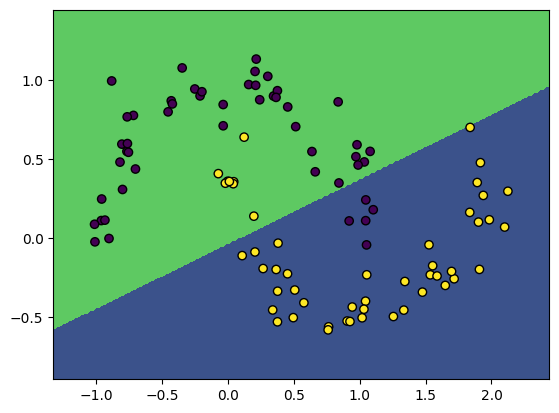

In [49]:
def LinearLoss(pred, y):
    LL = (2*y-1)*pred
    return LL.sum()

model = LogisticRegression(2)
optimizer = optim.SGD([model.weights, model.bias], lr=0.1)

for i in range(20):
    predictions = model.predict_probability(X)
    loss = LinearLoss(predictions, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(loss.item())

plot_boundary(model, X, y)

You would end up with negative loss, which doesn't makes sense conceptually.

## torch.nn

While PyTorch as a tool for automatic differentiation and optimization would be useful by itself. It actually gives us a lot more than that!

On of the most important features of PyTorch is its model-building tools in the `torch.nn` module. This gives us a lot of powerful features that we can use to build complex neural networks!



In [50]:
from torch import nn

Let's start by building out logistic regression model in the `torch.nn` framework. In order for a model to benefit from `torch.nn` our model class needs to inheret from `nn.Module`

In [51]:
class LogisticRegression(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.weights = nn.Parameter(torch.ones((dims,)))
        self.bias = nn.Parameter(torch.zeros(()))

    def forward(self, X):
        return torch.sigmoid(torch.matmul(X, self.weights) + self.bias)

    def predict_probability(self, X):
        return self.forward(X)

    def predict(self, X):
        return self.forward(X) > 0.5

There are 2 changes to note here. The first is that we wrapped our `weights` and `bias` terms in `nn.Parameter`. This tells PyTorch that these are the parameters we will want to optimize. We don't need to specify `requires_grad` for parameters, PyTorch will take care of that for us.

The second is that we moved the implmentation of `predict_probability` to `forward`. In PyTorch models the `forward` method is special, it defines the model as a function. If we call the model as a function `forward` will be called internally.

In [52]:
model = LogisticRegression(2)
model(X)

tensor([0.7840, 0.8158, 0.9010, 0.5565, 0.4349, 0.7770, 0.3300, 0.6926, 0.5503,
        0.7064, 0.5937, 0.2999, 0.5103, 0.5835, 0.8468, 0.7565, 0.4484, 0.8113,
        0.4170, 0.9164, 0.7878, 0.9269, 0.7368, 0.6256, 0.3063, 0.8806, 0.2845,
        0.7563, 0.2629, 0.4615, 0.5445, 0.5291, 0.2884, 0.7663, 0.5864, 0.5416,
        0.5157, 0.5890, 0.7607, 0.7908, 0.8975, 0.9184, 0.8811, 0.7836, 0.8281,
        0.8154, 0.4996, 0.8203, 0.7651, 0.6673, 0.7328, 0.6664, 0.9041, 0.8361,
        0.7472, 0.7797, 0.4980, 0.7863, 0.8103, 0.7829, 0.5981, 0.7441, 0.6632,
        0.6240, 0.5295, 0.8457, 0.4466, 0.6810, 0.5817, 0.5419, 0.7724, 0.6756,
        0.6088, 0.6061, 0.7936, 0.5994, 0.6945, 0.5862, 0.8908, 0.4712, 0.5955,
        0.7988, 0.3800, 0.7539, 0.7672, 0.7940, 0.5016, 0.6558, 0.8151, 0.4480,
        0.6823, 0.4598, 0.5187, 0.7943, 0.7788, 0.6753, 0.5446, 0.6414, 0.5835,
        0.5918], grad_fn=<SigmoidBackward0>)

This means that we can use instances of `nn.Module` as parameterized functions. For example, we might create a general linear (technically affine) function in the same way.

$$f(\mathbf{x}) = \mathbf{x}^T\mathbf{W}^T + \mathbf{b},  \quad f: \mathbb{R}^i \rightarrow \mathbb{R}^o$$

Note that here we are **not** assuming an augmented representation of $\mathbf{x}$.

In [53]:
class Linear(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.weightsT = nn.Parameter(torch.ones((inputs, outputs)))
        self.bias = nn.Parameter(torch.zeros((outputs,)))

    def forward(self, X):
        return torch.matmul(X, self.weightsT) + self.bias

We can use this module to implement out logistic regression model above.

In [54]:
class LogisticRegression(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.linear = Linear(dims, 1)                       # Dims input 1 output

    def forward(self, X):
        return torch.sigmoid(self.linear(X)).reshape((-1,)) # Turn output into a vector

    def predict_probability(self, X):
        return self.forward(X)

    def predict(self, X):
        return self.forward(X) > 0.5

In [55]:
model = LogisticRegression(2)
model(X)

tensor([0.7840, 0.8158, 0.9010, 0.5565, 0.4349, 0.7770, 0.3300, 0.6926, 0.5503,
        0.7064, 0.5937, 0.2999, 0.5103, 0.5835, 0.8468, 0.7565, 0.4484, 0.8113,
        0.4170, 0.9164, 0.7878, 0.9269, 0.7368, 0.6256, 0.3063, 0.8806, 0.2845,
        0.7563, 0.2629, 0.4615, 0.5445, 0.5291, 0.2884, 0.7663, 0.5864, 0.5416,
        0.5157, 0.5890, 0.7607, 0.7908, 0.8975, 0.9184, 0.8811, 0.7836, 0.8281,
        0.8154, 0.4996, 0.8203, 0.7651, 0.6673, 0.7328, 0.6664, 0.9041, 0.8361,
        0.7472, 0.7797, 0.4980, 0.7863, 0.8103, 0.7829, 0.5981, 0.7441, 0.6632,
        0.6240, 0.5295, 0.8457, 0.4466, 0.6810, 0.5817, 0.5419, 0.7724, 0.6756,
        0.6088, 0.6061, 0.7936, 0.5994, 0.6945, 0.5862, 0.8908, 0.4712, 0.5955,
        0.7988, 0.3800, 0.7539, 0.7672, 0.7940, 0.5016, 0.6558, 0.8151, 0.4480,
        0.6823, 0.4598, 0.5187, 0.7943, 0.7788, 0.6753, 0.5446, 0.6414, 0.5835,
        0.5918], grad_fn=<ViewBackward0>)

The power here is that because `Linear` is also an instance of `nn.Module`, PyTorch knows that it's weights should also be considered part of our models weights. We can access the weights of a model using the `parameters()` method.

In [56]:
list(model.parameters())

[Parameter containing:
 tensor([[1.],
         [1.]], requires_grad=True),
 Parameter containing:
 tensor([0.], requires_grad=True)]

This lets us easily apply gradient descent:

In [57]:
optimizer = optim.SGD(model.parameters(), lr=0.1)

for i in range(10):
    predictions = model(X)        # Now we can just call model!
    loss = NLL(predictions, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(loss.item())

76.44432830810547
49.23303985595703
47.19414520263672
36.620628356933594
34.37439727783203
32.638671875
31.851316452026367
31.326274871826172
31.00820541381836
30.786470413208008


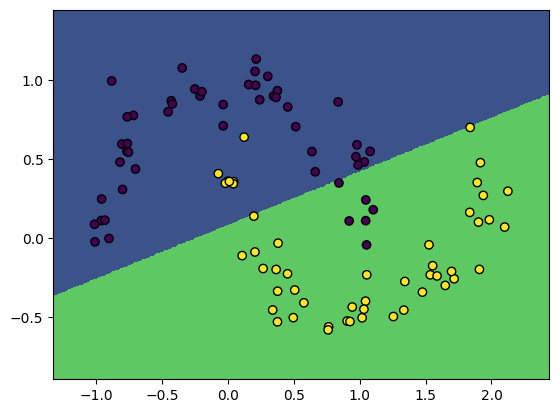

In [58]:
plot_boundary(model, X, y)

PyTorch unsurprisingly also provides a built-in `Linear` module. As `nn.Linear`.

In [59]:
nn.Linear(2, 1)

Linear(in_features=2, out_features=1, bias=True)

Knowing how to make a parameterized function in PyTorch, let's consider making a neural network layer with a sigmoid activation function.

$$f(\mathbf{x}) = \sigma(\mathbf{x}^T\mathbf{W}^T + \mathbf{b})$$

In [60]:
class SigmoidLayer(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.linear = nn.Linear(inputs, outputs)

    def forward(self, X):
        return torch.sigmoid(self.linear(X))
        

Let's create a layer with 10 neurons. (So $\mathbf{W}:\ (10 \times 2)$)

In [61]:
layer = SigmoidLayer(2, 10)
print(X.shape)
layer(X).shape

torch.Size([100, 2])


torch.Size([100, 10])

Let's use this to create a neural network class for binary classification!

In [62]:
class NeuralNetwork(nn.Module):
    def __init__(self, dims, hidden_size):
        super().__init__()
        self.layer = SigmoidLayer(dims, hidden_size)
        self.linear = Linear(hidden_size, 1)                       

    def forward(self, X):
        hidden_neurons = self.layer(X)
        output = self.linear(hidden_neurons)
        return torch.sigmoid(output).reshape((-1,))

    def predict_probability(self, X):
        return self.forward(X)

    def predict(self, X):
        return self.forward(X) > 0.5

We see that PyTorch recognizes both the parameters of the logistic regression and the parameters of our neural network feature transform:

In [63]:
model = NeuralNetwork(2, 10)
list(model.parameters())

[Parameter containing:
 tensor([[ 0.6271,  0.1711],
         [-0.1168,  0.0557],
         [-0.5382, -0.1672],
         [-0.2621,  0.4180],
         [ 0.3073,  0.2619],
         [ 0.5297,  0.6952],
         [-0.2711, -0.5614],
         [ 0.2924, -0.5263],
         [ 0.6409,  0.3901],
         [-0.1901,  0.5844]], requires_grad=True),
 Parameter containing:
 tensor([-0.0712, -0.2910,  0.4977, -0.2441, -0.2268,  0.4947,  0.3841,  0.5063,
          0.1365, -0.4974], requires_grad=True),
 Parameter containing:
 tensor([[1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.]], requires_grad=True),
 Parameter containing:
 tensor([0.], requires_grad=True)]

This means that we can easily run our optimization as before.

In [64]:
optimizer = optim.SGD(model.parameters(), lr=0.1)

for i in range(100):
    predictions = model(X)        # Now we can just call model!
    loss = NLL(predictions, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(loss.item())

267.58740234375
514.7208862304688
67.13326263427734
65.01707458496094
62.81396484375
60.42082977294922
58.06686019897461
55.88690185546875
54.363426208496094
53.15730285644531
52.52072525024414
51.49122619628906
50.4366455078125
48.4471435546875
46.61988830566406
43.831939697265625
41.9199104309082
39.92403030395508
39.097572326660156
39.757869720458984
40.882728576660156
45.13298416137695
44.54663848876953
45.92337417602539
40.58382034301758
38.551116943359375
35.715736389160156
35.57697296142578
35.18378829956055
36.90937042236328
37.122047424316406
39.739986419677734
38.2331428527832
39.46278381347656
36.65630340576172
36.873390197753906
35.04336166381836
35.63353729248047
34.67648696899414
35.787567138671875
34.957847595214844
36.27341079711914
35.074432373046875
36.22477722167969
34.72144317626953
35.64800262451172
34.19366455078125
35.05918502807617
33.79077911376953
34.700592041015625
33.54761505126953
34.50413513183594
33.36941909790039
34.33094787597656
33.17503356933594
34.10

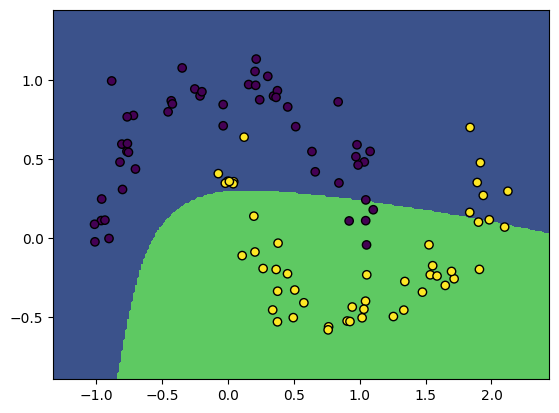

In [65]:
plot_boundary(model, X, y)

PyTorch also gives us an easier (but less flexible) way to define a composition of modules like this. In PyTorch we can define this simple network using `nn.Sequential`

In [66]:
model = nn.Sequential(
    nn.Linear(2, 10),
    nn.Sigmoid(),
    nn.Linear(10, 1),
    nn.Sigmoid(),
)
model(X).reshape((-1,))

tensor([0.3549, 0.3589, 0.3418, 0.3600, 0.3839, 0.3723, 0.3860, 0.3775, 0.3519,
        0.3439, 0.3500, 0.3849, 0.3602, 0.3676, 0.3377, 0.3427, 0.3865, 0.3399,
        0.3859, 0.3443, 0.3722, 0.3479, 0.3556, 0.3484, 0.3845, 0.3422, 0.3854,
        0.3758, 0.3844, 0.3585, 0.3582, 0.3903, 0.3831, 0.3644, 0.3630, 0.3563,
        0.3867, 0.3728, 0.3536, 0.3741, 0.3376, 0.3395, 0.3406, 0.3701, 0.3595,
        0.3406, 0.3667, 0.3575, 0.3750, 0.3814, 0.3520, 0.3805, 0.3433, 0.3576,
        0.3628, 0.3758, 0.3568, 0.3428, 0.3581, 0.3534, 0.3496, 0.3453, 0.3764,
        0.3502, 0.3653, 0.3646, 0.3857, 0.3447, 0.3729, 0.3617, 0.3679, 0.3838,
        0.3834, 0.3831, 0.3420, 0.3720, 0.3502, 0.3832, 0.3396, 0.3597, 0.3720,
        0.3430, 0.3843, 0.3737, 0.3592, 0.3405, 0.3872, 0.3489, 0.3447, 0.3855,
        0.3733, 0.3860, 0.3633, 0.3764, 0.3720, 0.3805, 0.3518, 0.3486, 0.3743,
        0.3725], grad_fn=<ViewBackward0>)

Here `nn.Sigmoid` is a built-in module that just applies the sigmoid function. Its implementation would look like:

In [67]:
class SigmoidLayer(nn.Module):
    def forward(self, X):
        return torch.sigmoid(X)

We could use this to create a network with several hidden layers:

In [68]:
model = nn.Sequential(
    nn.Linear(2, 10),
    nn.Sigmoid(),
    nn.Linear(10, 10),
    nn.Sigmoid(),
    nn.Linear(10, 10),
    nn.Sigmoid(),
    nn.Linear(10, 1),
    nn.Sigmoid(),
)
model(X)

tensor([[0.5271],
        [0.5271],
        [0.5273],
        [0.5269],
        [0.5268],
        [0.5270],
        [0.5267],
        [0.5270],
        [0.5269],
        [0.5271],
        [0.5270],
        [0.5267],
        [0.5269],
        [0.5269],
        [0.5272],
        [0.5271],
        [0.5268],
        [0.5271],
        [0.5268],
        [0.5273],
        [0.5270],
        [0.5273],
        [0.5271],
        [0.5270],
        [0.5267],
        [0.5272],
        [0.5267],
        [0.5270],
        [0.5267],
        [0.5269],
        [0.5269],
        [0.5268],
        [0.5267],
        [0.5271],
        [0.5269],
        [0.5269],
        [0.5268],
        [0.5269],
        [0.5271],
        [0.5270],
        [0.5273],
        [0.5273],
        [0.5272],
        [0.5270],
        [0.5271],
        [0.5271],
        [0.5269],
        [0.5271],
        [0.5270],
        [0.5269],
        [0.5271],
        [0.5269],
        [0.5273],
        [0.5271],
        [0.5270],
        [0

PyTorch also provides built-in loss functions. The PyTorch function for the negative log-likelihood for logistic regression is called `nn.functional.binary_cross_entropy`. It has some sharp edges though. 

For one, it expects `y` to be a float type. We can convert a PyTorch `int` tensor into a `float` one by calling the `float` method.

We also see that our sequential model returns a column vector, so `y` should match that as well.

In [69]:
optimizer = optim.SGD(model.parameters(), lr=0.1)

yfloat = y.float().reshape((-1, 1))

for i in range(100):
    predictions = model(X)        # Now we can just call model!
    loss = nn.functional.binary_cross_entropy(predictions, yfloat)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(loss.item())

0.6945114135742188
0.6942595839500427
0.6940505504608154
0.6938770413398743
0.6937330365180969
0.693613588809967
0.6935144066810608
0.693432092666626
0.6933636665344238
0.6933068633079529
0.6932596564292908
0.6932204961776733
0.6931878924369812
0.6931607723236084
0.6931381821632385
0.6931193470954895
0.6931036114692688
0.6930906176567078
0.6930797100067139
0.6930705308914185
0.6930628418922424
0.6930564045906067
0.6930509209632874
0.6930463314056396
0.6930423974990845
0.6930390000343323
0.6930361986160278
0.693033754825592
0.6930316090583801
0.6930297613143921
0.6930280923843384
0.6930267214775085
0.6930253505706787
0.693024218082428
0.6930230855941772
0.6930222511291504
0.693021297454834
0.6930204629898071
0.693019688129425
0.6930189728736877
0.6930182576179504
0.6930176019668579
0.6930168867111206
0.6930162906646729
0.6930156946182251
0.6930149793624878
0.6930145025253296
0.6930139064788818
0.6930133104324341
0.6930127143859863
0.6930121779441833
0.6930116415023804
0.6930110454559326

Let's take a look at a critical, but often overlooked detail of how neural networks work to understand some of the other nice things that PyTorch gives us.

#### **Q19:** Using custom Layers (5 points)

Copy the code above to define and train a neural network with 4 hidden layers (each with 10 neurons) and sigmoid activations, but this time replace the PyTorch-defined `nn.Linear` layers with the `Linear` layer we defined above.

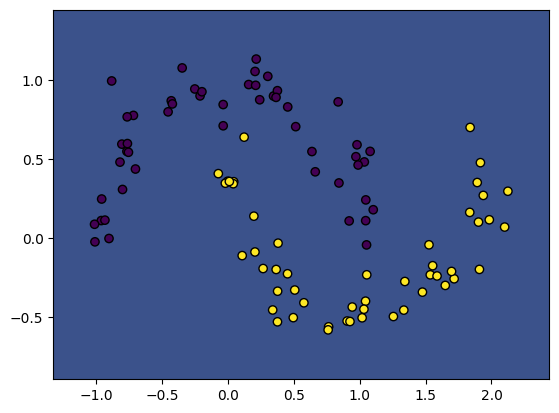

In [70]:
class SigmoidLayer(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.linear = Linear(inputs, outputs)

    def forward(self, X):
        return torch.sigmoid(self.linear(X))

class Linear(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.weights = nn.Parameter(torch.zeros((inputs, outputs)))
        self.bias = nn.Parameter(torch.zeros(outputs, ))
    def forward(self, X):
        return torch.matmul(X, self.weights) + self.bias

class CustomNetwork(nn.Module):
    def __init__(self, dims, hiddensize):
        super().__init__()
        self.inputLayer = SigmoidLayer(dims, hiddensize)
        self.hiddenLayer1 = SigmoidLayer(hiddensize, hiddensize)
        self.hiddenLayer2 = SigmoidLayer(hiddensize, hiddensize)
        self.hiddenLayer3 = SigmoidLayer(hiddensize, hiddensize)
        self.linear = Linear(hiddensize, 1)
        
    def forward(self, X):
        h1 = self.inputLayer(X)
        h2 = self.hiddenLayer1(h1)
        h3 = self.hiddenLayer2(h2)
        h4 = self.hiddenLayer3(h3)
        output = self.linear(h4)
        return torch.sigmoid(output)
        
    def predict_probability(self, X):
        return self.forward(X)
        
    def predict(self, X):
        return self.forward(X)>0.5
        
model = CustomNetwork(2, 10)
optimizer = optim.SGD(model.parameters(), lr=0.01)

for i in range(100000):
    predictions = model(X)        # Now we can just call model!
    loss = NLL(predictions, yfloat)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
plot_boundary(model, X, y)

Does this version of the network work as well? What do you notice about the parameters that it learned?

This version works really poorly, as the parameters its learns results in it always predicting 1.

What you should be seeing is a classic problem for neural networks: initialization! In our implementation we initialized all of the parameters to $0$, which was reasonable for logistic regression. Unfortunately for neural networks this symmertical initialization can cause problems. We won't go into all the details here, but the basic reasoning is that if 2 neurons have the same weights and the same inputs, there's no way to distinguish them! Gradient descent doesn't help because the gradients for each neuron will be identical as well, so we're left in a situation where we can never separate out two identical neurons.

The classic solution to this issue is simply to initialize all of our weights randomly.

#### **Q20:** Random initialization (5 points)

Modify the `Linear` implementation from above to initialize the `weights` and `bias` parameters from a *standard normal* distribution $w,b \sim \mathcal{N}(0, 1)$. Then modify your model from the previous question to use this new module.

***Hint:** You may find the `torch.randn` function useful here. You might also find that the model doesn't train! We'll address this in the next question.*

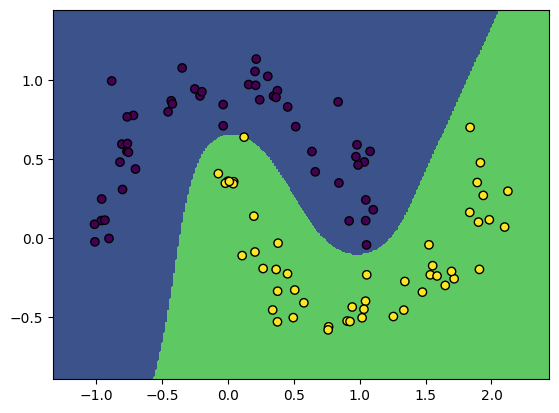

In [71]:
class SigmoidLayer(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.linear = LinearNormal(inputs, outputs)

    def forward(self, X):
        return torch.sigmoid(self.linear(X))
        
class LinearNormal(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.weights = nn.Parameter(torch.randn((inputs, outputs)))
        self.bias = nn.Parameter(torch.randn((outputs, )))

    def forward(self, X):
        return torch.matmul(X, self.weights) + self.bias

class CustomNetwork(nn.Module):
    def __init__(self, dims, hiddensize):
        super().__init__()
        self.inputLayer = SigmoidLayer(dims, hiddensize)
        self.hiddenLayer1 = SigmoidLayer(hiddensize, hiddensize)
        self.hiddenLayer2 = SigmoidLayer(hiddensize, hiddensize)
        self.hiddenLayer3 = SigmoidLayer(hiddensize, hiddensize)
        self.linear = LinearNormal(hiddensize, 1)
        
    def forward(self, X):
        h1 = self.inputLayer(X)
        h2 = self.hiddenLayer1(h1)
        h3 = self.hiddenLayer2(h2)
        h4 = self.hiddenLayer3(h3)
        output = self.linear(h4)
        return torch.sigmoid(output)
        
    def predict_probability(self, X):
        return self.forward(X)
        
    def predict(self, X):
        return self.forward(X)>0.5
        
model = CustomNetwork(2, 50)
optimizer = optim.SGD(model.parameters(), lr=0.01)

for i in range(10000):
    predictions = model(X)        # Now we can just call model!
    loss = nn.functional.binary_cross_entropy(predictions, yfloat)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

plot_boundary(model, X, y)

What did you observe happened here? Did it work as well as the default PyTorch `nn.Linear` layer? Try increasing and decreasing the number of neurons per layer.

This version works much better, but with 10 neurons it essentially learns a linear function to seperate the two classes. Decreasing the number of neurons seems to shift the slope of the linear function, but increasing the number neurons allows it to learn a non-linear and complex function that can better classify the data. With a really high number of neurons per layer (40), it is able to consistently perfectly classify the training data.

#### **Q21:** Kaiming initialization (5 points)

The issues you see here are caused by the variances of the neuron outputs being too large! Again, we won't go into much detail here, but the core of the issue is that the more inputs a neuron has, the larger the scale of its values will be. This can cause gradients to end up very large making optimization difficult. We can account for this by scaling down our weights to account for this.

A common, useful approach for initializing neural networks is to use a *Kaiming normal* initialization. In this approach we draw each initial weight from a normal distribution where the standard deviation is scaled by the square root of the number of input dimensions to the layer. If $\mathbf{W} \in \mathbb{R}^{d\times e}$ then:
$$w_{ij} \sim \mathcal{N}\bigg(0, \frac{1}{\sqrt{d}}\bigg) \quad \mathbf{W}: d \times e$$
$$b_j = 0 \quad \mathbf{b}: e$$
We'll initialize the biases to $0$. Below, implement a linear module using the Kaiming normal initialization, then repeat the previous question using this new layer.

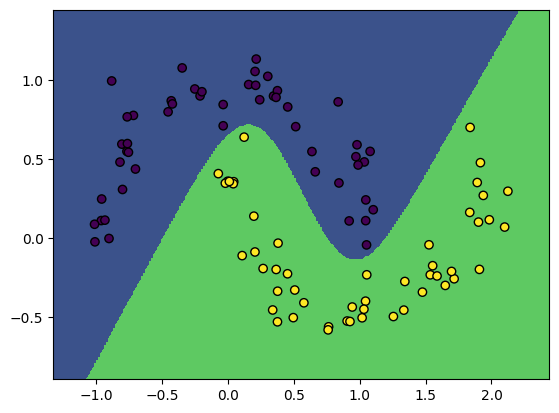

In [72]:
class LinearKaiming(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(inputs, outputs))
        self.bias = nn.Parameter(torch.zeros((outputs,)))

        std = 1 / math.sqrt(inputs)
        nn.init.normal_(self.weights, mean=0.0, std=std)

    def forward(self, X):
        return torch.matmul(X, self.weights) + self.bias

class SigmoidLayer(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.linear = LinearKaiming(inputs, outputs)

    def forward(self, X):
        return torch.sigmoid(self.linear(X))
        
class CustomNetwork(nn.Module):
    def __init__(self, dims, hiddensize):
        super().__init__()
        self.inputLayer = SigmoidLayer(dims, hiddensize)
        self.hiddenLayer1 = SigmoidLayer(hiddensize, hiddensize)
        self.hiddenLayer2 = SigmoidLayer(hiddensize, hiddensize)
        self.hiddenLayer3 = SigmoidLayer(hiddensize, hiddensize)
        self.linear = LinearKaiming(hiddensize, 1)
        
    def forward(self, X):
        h1 = self.inputLayer(X)
        h2 = self.hiddenLayer1(h1)
        h3 = self.hiddenLayer2(h2)
        h4 = self.hiddenLayer3(h3)
        output = self.linear(h4)
        return torch.sigmoid(output)
        
    def predict_probability(self, X):
        return self.forward(X)
        
    def predict(self, X):
        return self.forward(X)>0.5
        
model = CustomNetwork(2, 10)
optimizer = optim.SGD(model.parameters(), lr=0.01)

for i in range(100000):
    predictions = model(X)        # Now we can just call model!
    loss = nn.functional.binary_cross_entropy(predictions, yfloat)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
plot_boundary(model, X, y)

## Evaluating models

For convinience going forward, let's definie a wrapper class for our model.

In [73]:
class LogisticRegressionNeuralNetwork(nn.Module):
    def __init__(self, network):
        super().__init__()
        self.network = network                   

    def forward(self, X):
        return self.network(X).reshape((-1,))

    def predict_probability(self, X):
        return self.forward(X)

    def predict(self, X):
        return self.forward(X) > 0.5

We see that we have a *lot* of options when designing a neural network. So far the choices we've seen are:
- The number of layers
- The number of neurons in each layer
- The activation function
- The learning rate for gradient descent

And this is just the beginning! As we go on, we'll learn about many more options that we have.

Let's take a look at how to make some of these choices. In many real cases, our data will not be a cleanly separated into 2 classes as we've seen. For instance, we can look at a noisier version of the dataset we saw before.

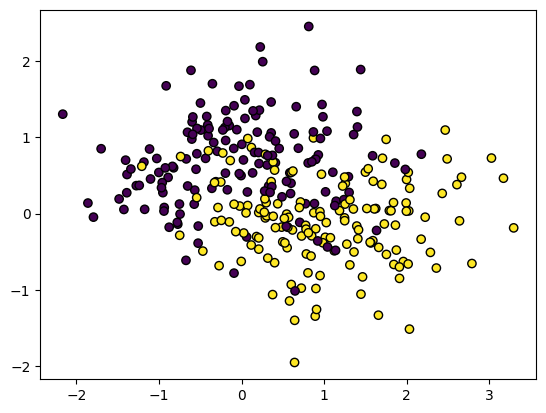

In [74]:
X, y = make_moons(300, noise=0.5)
X, y = torch.tensor(X).float(), torch.tensor(y)
plt.scatter(*X.T, c=y, edgecolor="black")

In reality, this dataset was drawn from the distribution shown below! The optimal classifier would still have an "s-shaped" decision boundary

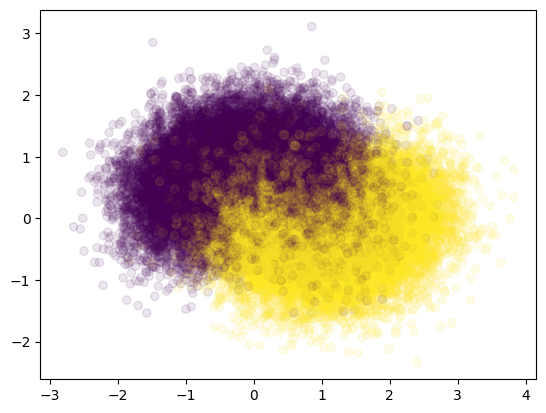

In [75]:
X, y = make_moons(50000, noise=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.1)
pass

Let's split this into training and test sets as we've seen.

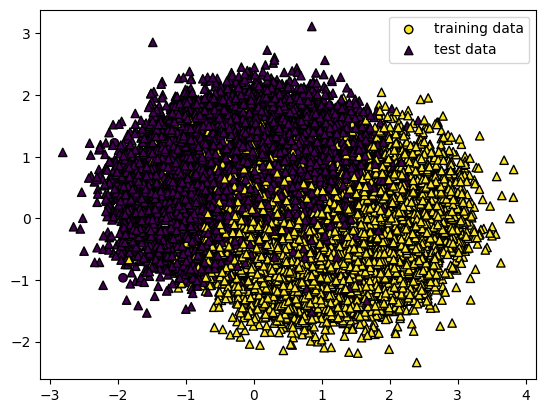

In [76]:
inds = np.arange(X.shape[0])
np.random.shuffle(inds)
Xtrain, ytrain = X[inds[:150]], y[inds[:150]]
Xtest, ytest = X[inds[150:]], y[inds[150:]]

# We can plot training and test data on the same plot
plt.scatter(*Xtrain.T, c=ytrain, edgecolor="black", marker='o', label='training data')
plt.scatter(*Xtest.T, c=ytest, edgecolor="black", marker='^', label='test data')
plt.legend()


## Underfittting

We'll start by fitting a logistic regression model as we've seen. This time we'll keep track of the loss on both the training data and the test data.

In [77]:
network = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.1)
Xtrain = torch.tensor(Xtrain, dtype = torch.float32)
ytrain = torch.tensor(ytrain)
Xtest = torch.tensor(Xtest, dtype = torch.float32)
ytest = torch.tensor(ytest)
train_losses, test_losses = [], []
pbar = tqdm.trange(2500)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())

Loss: 0.476: 100%|████████████████████████| 2500/2500 [00:01<00:00, 1385.71it/s]


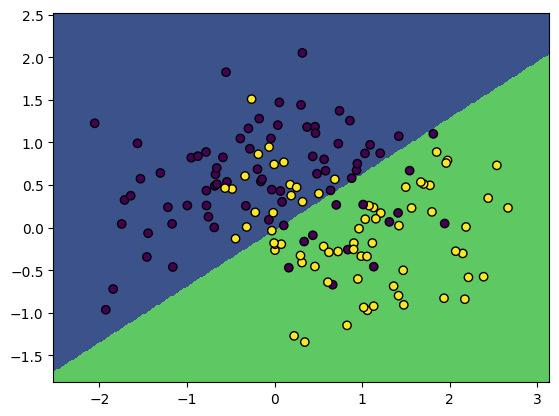

In [78]:
plot_boundary(model, Xtrain, ytrain)

Let's compute the accuracy on both the training and the test data

In [79]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
test_acc = (model.predict(Xtest) == ytest).float().mean()
print('Training accuracy: %.3f, Test accuracy: %.3f' % (train_acc, test_acc))

Training accuracy: 0.780, Test accuracy: 0.805


We can also look at how the loss on both the training and test data changes as we run gradient descent.

Text(0.5, 1.0, 'Loss vs. training iteration')

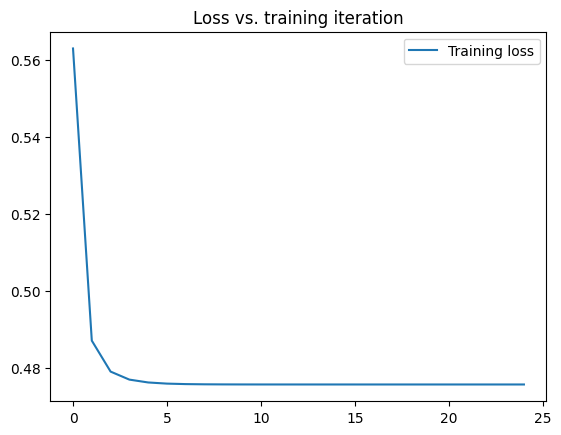

In [80]:
plt.plot(train_losses[:15000:100], label='Training loss')
#plt.plot(test_losses[:15000:100], label='Test loss')
plt.legend()
plt.title('Loss vs. training iteration')

Here wee see that both the training loss/accuracy and the test loss/accuracy are quite poor! From our descision boundary plot we can see quite clearly that this is a consequence of our choice of a linear model for this classification problem. We call this problem **underfitting**, meaning that our model is not expressive enough to capture all the intricacies of our data. As we've already seen we can address this by adding neural network layers to increase the expressivity of our model.

## Overfitting

Let's try creating a much more complex model; one with several large neural network layers and fitting it to our data.

In [81]:
network = nn.Sequential(
    nn.Linear(2, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.03)

train_losses, test_losses = [], []
pbar = tqdm.trange(25000)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())


Loss: 1.671: 100%|████████████████████████| 25000/25000 [10:17<00:00, 40.50it/s]


We can view the descision boundary and accuracy for this classifier.

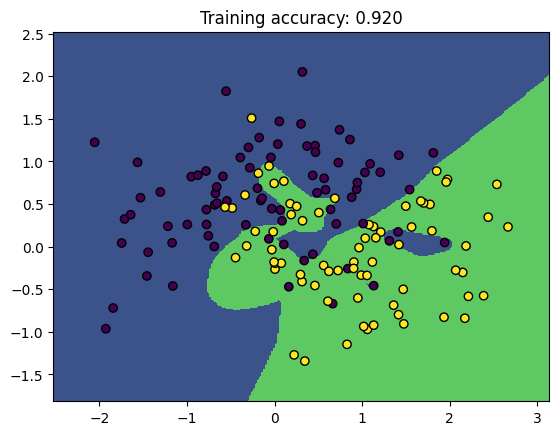

In [82]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
plot_boundary(model, Xtrain, ytrain, title='Training accuracy: %.3f' % train_acc)


We see that our model is much more expressive and basically correctly classifies every observation in our training dataset. This is great! However the boundary is quite complex. Let's see what happens when we evaluate on our test set.

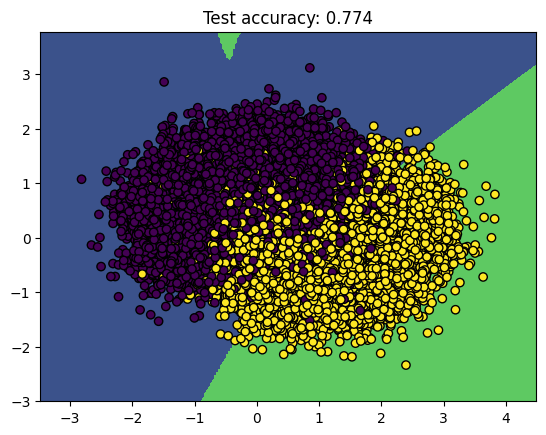

In [83]:
test_acc = (model.predict(Xtest) == ytest).float().mean()
plot_boundary(model, Xtest, ytest, title='Test accuracy: %.3f' % test_acc)


The accuracy is *much* worse. Rather than capturing the true distribution of classes, our model has captured the training set we happened to draw. This means if we draw a new dataset from the same distribution (like our test set), performance is poor. We call this issue **overfitting**.

Let's see how the training and test loss change over gradient descent.

Text(0.5, 1.0, 'Loss vs. training iteration')

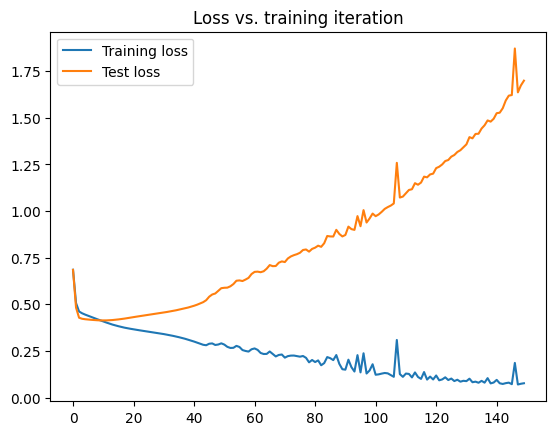

In [84]:
plt.plot(train_losses[:15000:100], label='Training loss')
plt.plot(test_losses[:15000:100], label='Test loss')
plt.legend()
plt.title('Loss vs. training iteration')

It's worth noting the the best solution to overfitting is to get more data. If we train with enough data we can avoid overfitting entirely.

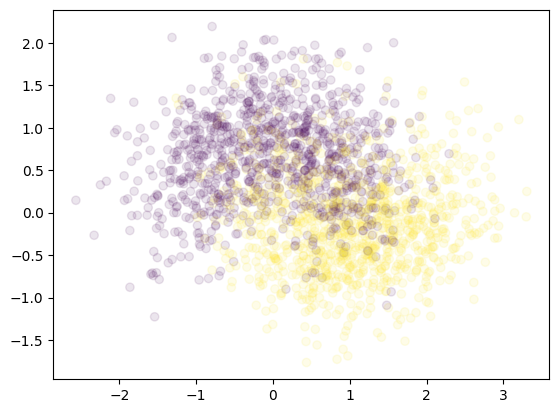

In [85]:
X, y = make_moons(2000, noise=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.1)

In [86]:
X, y = torch.tensor(X).float(), torch.tensor(y)
network = nn.Sequential(
    nn.Linear(2, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.1)

train_losses, test_losses = [], []
pbar = tqdm.trange(2500)
for i in pbar:
    predictions = model(X)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, y.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())

Loss: 0.384: 100%|██████████████████████████| 2500/2500 [01:03<00:00, 39.22it/s]


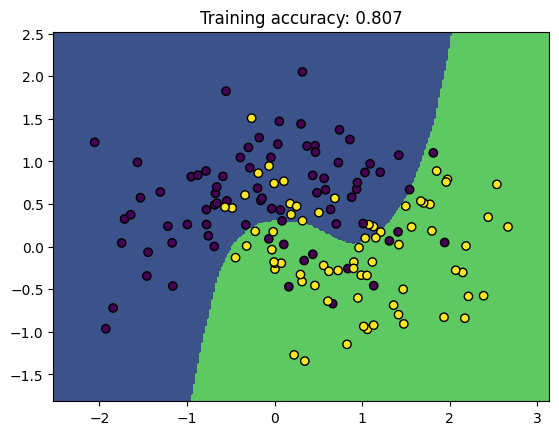

In [87]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
plot_boundary(model, Xtrain, ytrain, title='Training accuracy: %.3f' % train_acc)

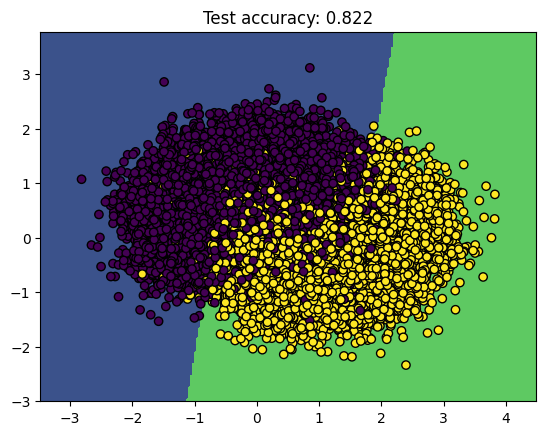

In [88]:
test_acc = (model.predict(Xtest) == ytest).float().mean()
plot_boundary(model, Xtest, ytest, title='Test accuracy: %.3f' % test_acc)

Text(0.5, 1.0, 'Loss vs. training iteration')

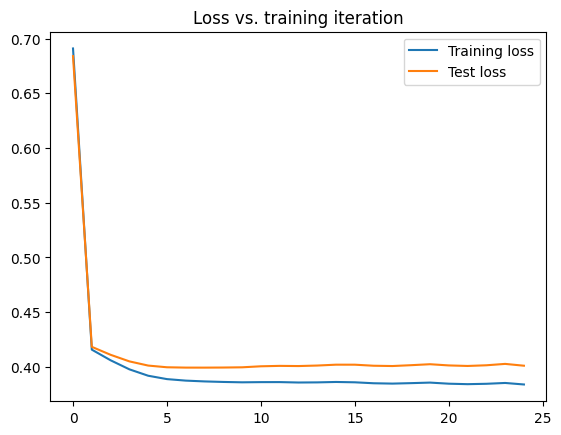

In [89]:
plt.plot(train_losses[:15000:100], label='Training loss')
plt.plot(test_losses[:15000:100], label='Test loss')
plt.legend()
plt.title('Loss vs. training iteration')

Unfortunately, this often isn't realistic. Data is hard to collect and more data means our model is slower and more expensive to train.

## Early stopping and regularization

Let's return to the original case

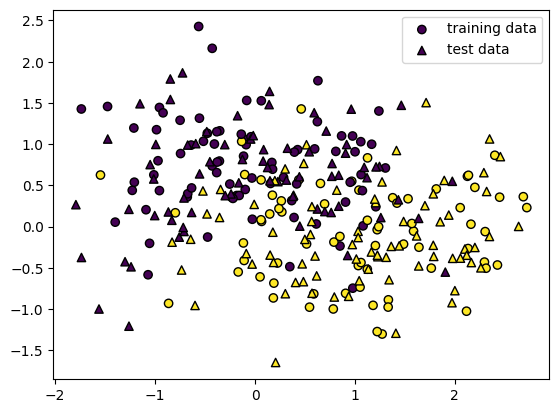

In [90]:
X, y = make_moons(300, noise=0.5)
X, y = torch.tensor(X).float(), torch.tensor(y)

inds = np.arange(X.shape[0])
np.random.shuffle(inds)
Xtrain, ytrain = X[inds[:150]], y[inds[:150]]
Xtest, ytest = X[inds[150:]], y[inds[150:]]

# We can plot training and test data on the same plot
plt.scatter(*Xtrain.T, c=ytrain, edgecolor="black", marker='o', label='training data')
plt.scatter(*Xtest.T, c=ytest, edgecolor="black", marker='^', label='test data')
plt.legend()

Let's try a network somewhere in-between, with just a single hidden layer.

In [91]:
network = nn.Sequential(
    nn.Linear(2, 100),
    nn.ReLU(),
    nn.Linear(100, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.03)

train_losses, test_losses = [], []
pbar = tqdm.trange(25000)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())

Loss: 0.377:  11%|██▌                    | 2830/25000 [00:01<00:12, 1791.00it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Loss: 0.349:  35%|████████▏              | 8874/25000 [00:05<00:10, 1603.20it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Loss: 0.331:  59%|████████████▉         | 14698/25000 [00:08<00:06, 1701.08it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashin

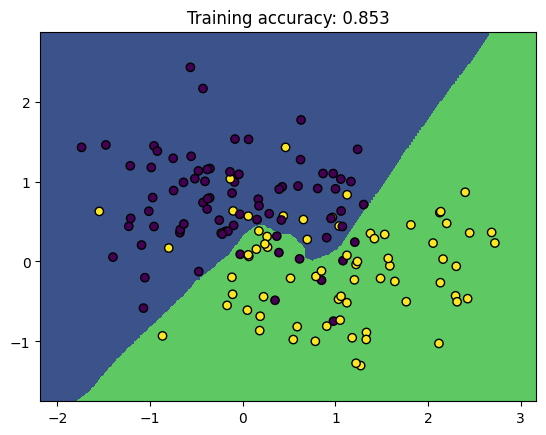

In [92]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
plot_boundary(model, Xtrain, ytrain, title='Training accuracy: %.3f' % train_acc)


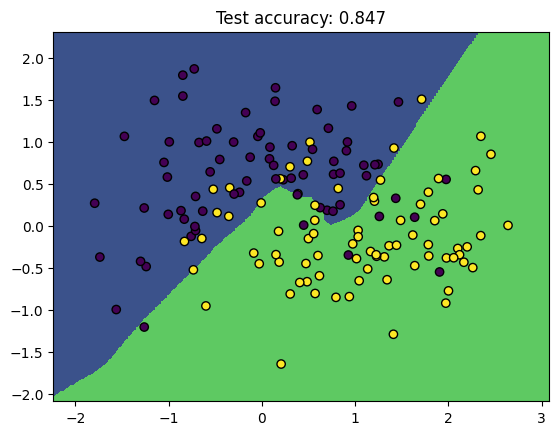

In [93]:
test_acc = (model.predict(Xtest) == ytest).float().mean()
plot_boundary(model, Xtest, ytest, title='Test accuracy: %.3f' % test_acc)

We see that this network is more consistent between train and test, and now performs better on test data! Let's take a look at the plot of training and test loss.

Text(0.5, 1.0, 'Loss vs. training iteration')

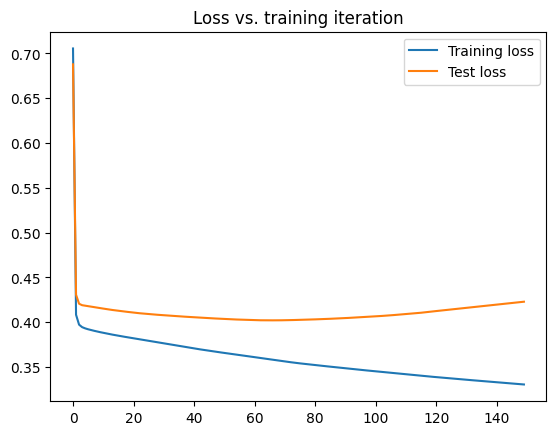

In [94]:
plt.plot(train_losses[:15000:100], label='Training loss')
plt.plot(test_losses[:15000:100], label='Test loss')
plt.legend()
plt.title('Loss vs. training iteration')

We still see that both drop quickly, but that test loss increases after a point. How might we use this to pick a better model?

One option would be to just use the model where the test loss is lowest. After all, that is our ultimate goal. There are different ways we can think about implementing this. One way to to have gradient descent stop when the test loss begins to increase. We call this approach **early stopping** 

In [95]:
network = nn.Sequential(
    nn.Linear(2, 100),
    nn.ReLU(),
    nn.Linear(100, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.03)

train_losses, test_losses = [], []
pbar = tqdm.trange(25000)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())

    if len(test_losses) > 1 and test_losses[-1] > test_losses[-2]:
        break

Loss: 0.370:  11%|██▌                    | 2835/25000 [00:01<00:13, 1595.21it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Text(0.5, 1.0, 'Loss vs. training iteration')

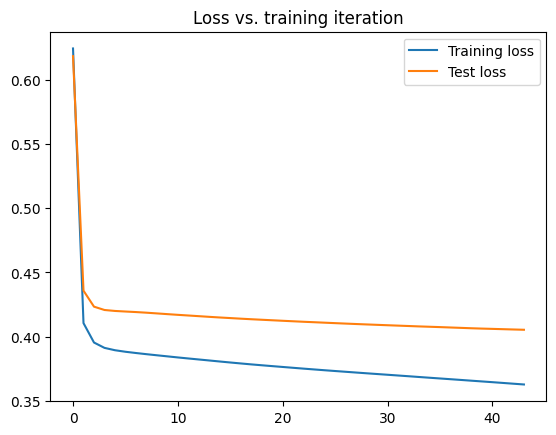

In [96]:
plt.plot(train_losses[:15000:100], label='Training loss')
plt.plot(test_losses[:15000:100], label='Test loss')
plt.legend()
plt.title('Loss vs. training iteration')

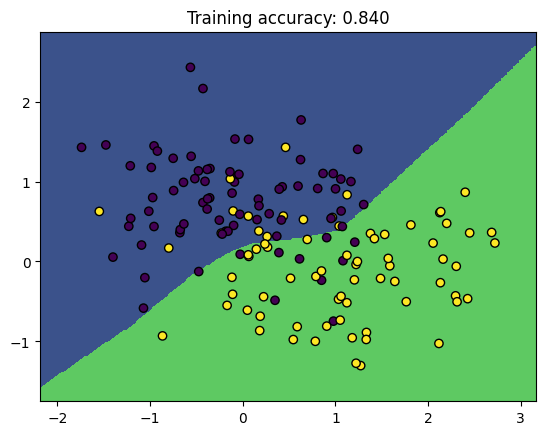

In [97]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
plot_boundary(model, Xtrain, ytrain, title='Training accuracy: %.3f' % train_acc)

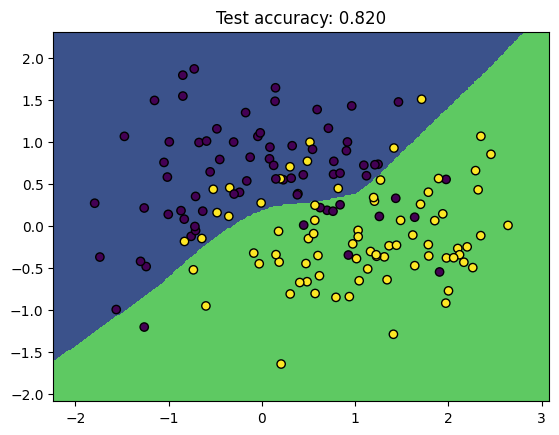

In [98]:
test_acc = (model.predict(Xtest) == ytest).float().mean()
plot_boundary(model, Xtest, ytest, title='Test accuracy: %.3f' % test_acc)

Here we see that actually we do the best so far with this approach!

We could also try our early-stopping approach with our more complex network.

In [99]:
network = nn.Sequential(
    nn.Linear(2, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.03)

train_losses, test_losses = [], []
pbar = tqdm.trange(25000)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())

    if len(test_losses) > 1 and test_losses[-1] > test_losses[-2]:
        break

Loss: 0.372:   4%|▉                       | 935/25000 [00:00<00:21, 1097.19it/s]


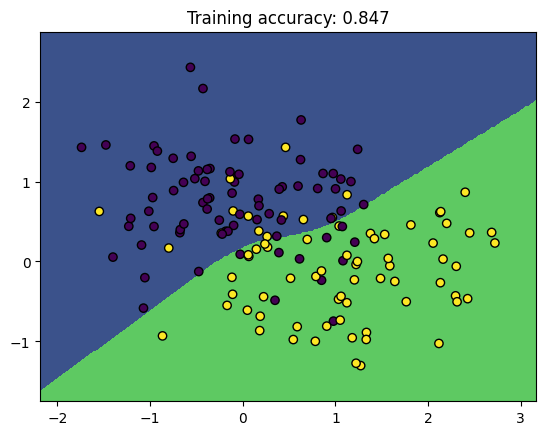

In [100]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
plot_boundary(model, Xtrain, ytrain, title='Training accuracy: %.3f' % train_acc)

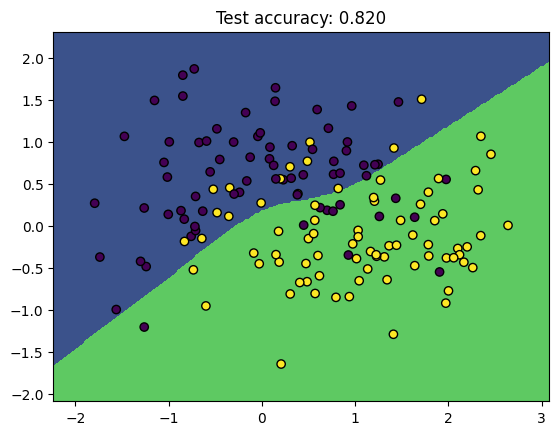

In [101]:
test_acc = (model.predict(Xtest) == ytest).float().mean()
plot_boundary(model, Xtest, ytest, title='Test accuracy: %.3f' % test_acc)

Text(0.5, 1.0, 'Loss vs. training iteration')

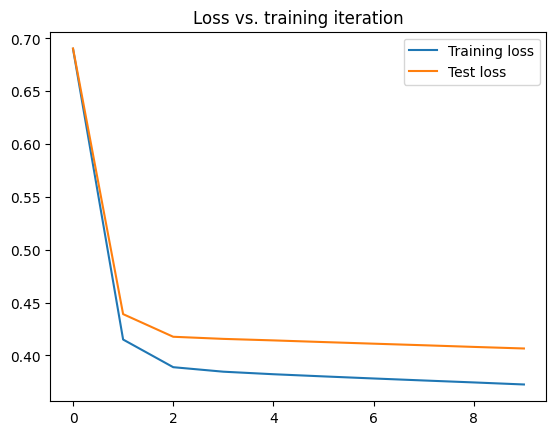

In [102]:
plt.plot(train_losses[:15000:100], label='Training loss')
plt.plot(test_losses[:15000:100], label='Test loss')
plt.legend()
plt.title('Loss vs. training iteration')

In practice you might find that the training and test loss don't always decrease *monotonically*. Sometimes the loss might fluctuate and go up before going down again. To account for this, it's often useful to use a more *patient* version of early stopping. In this case we might only want to stop when the test loss starts increasing consistently. 

#### **Q22** (10 points)

Copy and modify the early stopping gradient descent code above so that it always runs for at least 50 iterations. Then after 50 iterations stop if at any point the validation loss is larger than the *average validation loss for the previous 50 iterations*.



In [111]:
network = nn.Sequential(
    nn.Linear(2, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.03)

train_losses, test_losses = [], []
pbar = tqdm.trange(25000)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())

    if len(test_losses) > 50:
        avg = sum(test_losses[-50:])/50.00
        if test_loss.item() >avg:
            break

Loss: 0.398:   4%|▉                        | 914/25000 [00:01<00:26, 910.56it/s]


Another common method for reducing overfitting in neural networks is to use *L2 regularization*. This approach aims to minimize the orginal loss while also trying to minimize how large the weights are. We can think of it as minimizing a modified loss function:

$$\min_{\mathbf{w}} \textbf{Loss}(\mathbf{w}, \mathbf{X}, \mathbf{y}) + \lambda||\mathbf{w}||^2_2$$

Here $\lambda$ defines the trade-off between the two losses. In practice because the gradient of the L2-norm is trivial ($\frac{d}{d\mathbf{w}}  \lambda||\mathbf{w}||^2_2 = 2\lambda \mathbf{w}$), we can implement this as a simple modification to gradient descent:

$$ \mathbf{w}_{(t+1)} \leftarrow \mathbf{w}_{(t)} - \nabla_{\mathbf{w}_{(t)}}\textbf{Loss}(\mathbf{w}_{(t)}, \mathbf{X}, \mathbf{y}) - 2\lambda \mathbf{w}_{(t)}$$

*Here we're using subscripts to distinguish the parameters at iteration $t$ and the updated parameters at iteration $t+1$*

This approach is common enough that it's actually implemented by default into all of the basic PyTorch optimizers, under the name **weight decay** (as it encourages unused weights to *decay* toward 0). We can enable it by setting the `weight_decay` option of `optim.SGD` to something $>0$ as shown below (this corresponds to $\lambda$ as defined above).

/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_19670/2279350367.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X, y = torch.tensor(X).float(), torch.tensor(y)
Loss: 0.324: 100%|█████████████████████████| 2500/2500 [00:03<00:00, 690.86it/s]


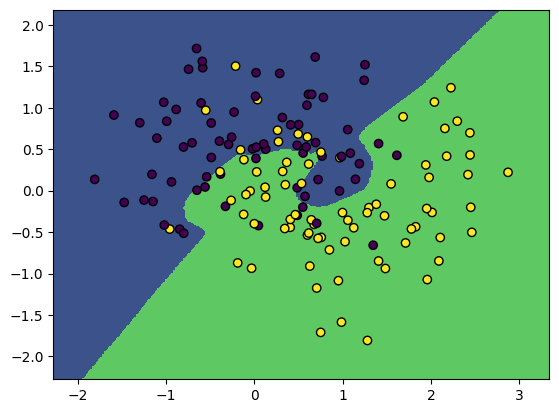

In [112]:
X, y = torch.tensor(X).float(), torch.tensor(y)
network = nn.Sequential(
    nn.Linear(2, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)

train_losses, test_losses = [], []
pbar = tqdm.trange(2500)
for i in pbar:
    predictions = model(X)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, y.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())
plot_boundary(model, Xtrain, ytrain)

#### **Q23** (5 points)

Try out different values for the `weight_decay` parameter in the cell above. How does the optimized decision boundary change as you change the value? Does it help prevent overfitting for this problem?

As weight_decay gets larger, the decision boundary becomes more rounded and less pronounced, with edges being smoothed over and the function approaching linearity. At weight_decay = 1, the network loses its ability to distinguish between classes and only predicts blue. As weight_decay gets smaller, the boundary becomes more jagged and nonlinear as it more closely fits to the training data. This shows that slightly larger values of weight_decay may prevent overfitting by smoothing over the decision boundary.

## Train, validation and test

There is an issue here though! We've now used out test set to (indirectly) train our model. Both by using it to choose the number of layers and by using it to determine how long to run our optimization! This means that our model choice will be biased by our choice of test set, so how can we trust that our test loss or accuracy will actually be a good measure of the real-world performance of our model?

To deal with this issue we will typically split our data into 3 parts that we'll call **training**, **validation** and **test**. We'll use the validation portion as the portion to fit the model and the test set as the portion we use to estimate how well it will do in practice.

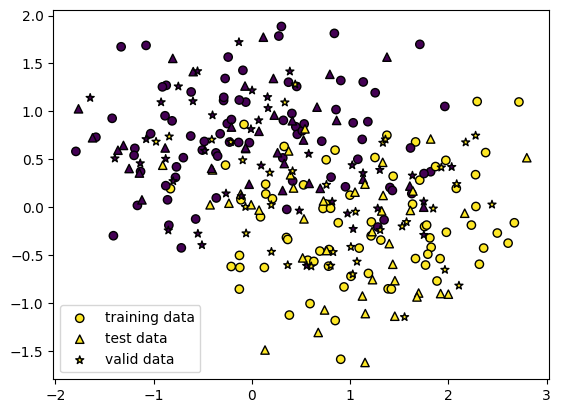

In [114]:
X, y = make_moons(300, noise=0.5)
X, y = torch.tensor(X).float(), torch.tensor(y)

inds = np.arange(X.shape[0])
np.random.shuffle(inds)
Xtrain, ytrain = X[inds[:150]], y[inds[:150]]
Xvalid, yvalid = X[inds[150:225]], y[inds[150:225]]
Xtest, ytest = X[inds[225:]], y[inds[225:]]

# We can plot training and test data on the same plot
plt.scatter(*Xtrain.T, c=ytrain, edgecolor="black", marker='o', label='training data')
plt.scatter(*Xtest.T, c=ytest, edgecolor="black", marker='^', label='test data')
plt.scatter(*Xvalid.T, c=yvalid, edgecolor="black", marker='*', label='valid data')
plt.legend()

In [118]:
network = nn.Sequential(
    nn.Linear(2, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.03)

train_losses, valid_losses = [], []
pbar = tqdm.trange(25000)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    valid_loss = torch.nn.functional.binary_cross_entropy(model(Xvalid), yvalid.flatten().float())
    valid_losses.append(valid_loss.item())

    if i > 50 and valid_loss.item() > valid_losses[-2]:
        break

Loss: 0.444:   0%|                          | 58/25000 [00:00<00:32, 770.37it/s]


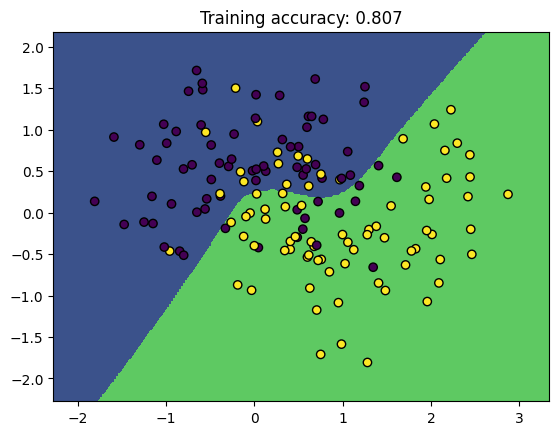

In [107]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
plot_boundary(model, Xtrain, ytrain, title='Training accuracy: %.3f' % train_acc)

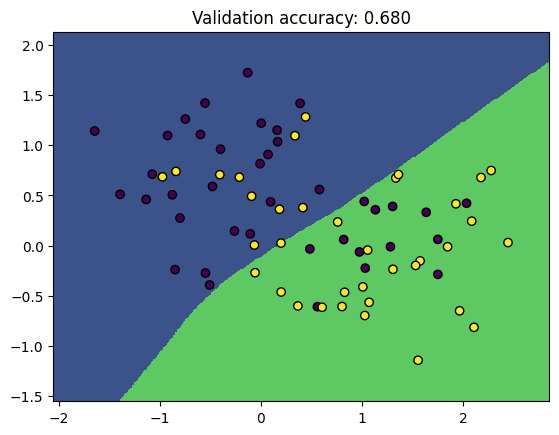

In [116]:
test_acc = (model.predict(Xvalid) == yvalid).float().mean()
plot_boundary(model, Xvalid, yvalid, title='Validation accuracy: %.3f' % test_acc)

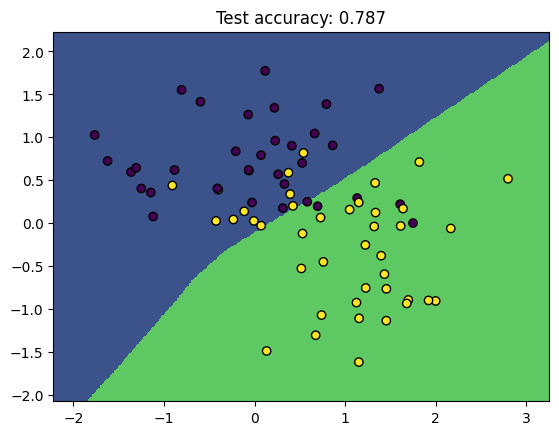

In [117]:
test_acc = (model.predict(Xtest) == ytest).float().mean()
plot_boundary(model, Xtest, ytest, title='Test accuracy: %.3f' % test_acc)